<a href="https://colab.research.google.com/github/isaacadebayo/Predictive-Analytics-Public-Datasets/blob/main/Apple_Stock_prediction_timeseries_split_fold4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install dvc[gdrive]

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Installing DVC

Let's install DVC. We'll use `dvc[gdrive]` for Google Drive integration, which is useful in Colab.

### Basic DVC Usage

To use DVC, you'll typically initialize a Git repository first, and then a DVC repository within it. For simplicity in Colab, we can skip the Git initialization if you only want to version data locally or with Google Drive as a remote. Let's set up a DVC remote to your Google Drive to store versioned data.

**Note:** You need to have git installed and initialize a git repo for DVC to work fully. If you haven't, please run !apt-get update && apt-get install git -y and then !git init in a separate cell before running the DVC commands.

**Setting up DVC with Google Drive:**

### Connecting Colab Git to GitHub

To connect your Colab environment to your GitHub repository, you'll need to configure Git with your user information and then either use an SSH key or a Personal Access Token (PAT) for authentication. Using a PAT is often simpler in Colab.

#### 1. Configure Git User Information

In [4]:
# Replace with your GitHub email and username
!git config --global user.email "isaac_adebayojr@gmail.com"
!git config --global user.name "isaacadebayo"

print("Git user configured.")

Git user configured.


#### 2. Authenticate with GitHub using a Personal Access Token (PAT)

GitHub requires authentication for many Git operations. A Personal Access Token (PAT) is a secure way to do this without exposing your password. If you don't have one, you can create it in your GitHub settings (Settings > Developer settings > Personal access tokens > Tokens (classic)). Give it the `repo` scope.

Once you have your PAT, you can use it to clone your repository.

In [5]:
# Store your GitHub PAT securely in Colab Secrets
# Click on the '🔑' icon on the left panel, add a new secret named 'GH_TOKEN' and paste your PAT there.
from google.colab import userdata
import os

# Get the PAT from Colab secrets
GH_TOKEN = userdata.get('GH_TOKEN')

# Set it as an environment variable (optional, but good practice if cloning private repos)
os.environ['GH_TOKEN'] = GH_TOKEN

print("GitHub Token retrieved. You can now use it for cloning private repositories.")

GitHub Token retrieved. You can now use it for cloning private repositories.


#### 3. Clone your GitHub Repository

Now you can clone your repository. For private repositories, you'll include your PAT in the URL.

In [6]:
# Replace 'your_username' and 'your_repository' with your actual GitHub details.
# For a public repository:
!git clone https://github.com/isaacadebayo/Predictive-Analytics-Public-Datasets.git

# For a private repository using PAT:
# This uses the GH_TOKEN environment variable
!git clone https://{GH_TOKEN}@github.com/isaacadebayo/Predictive-Analytics-Public-Datasets

# Change into your repository directory to perform Git operations
%cd Predictive-Analytics-Public-Datasets

print("Repository cloned. You are now in the repository directory.")

fatal: destination path 'Predictive-Analytics-Public-Datasets' already exists and is not an empty directory.
fatal: destination path 'Predictive-Analytics-Public-Datasets' already exists and is not an empty directory.
/content/Predictive-Analytics-Public-Datasets
Repository cloned. You are now in the repository directory.


In [7]:
# Initialize DVC within the current directory (which is the cloned Git repo)
!dvc init

# Configure Google Drive as a remote storage (replace 'dvc_storage' with your desired folder name in Google Drive)
!dvc remote add -d gdrive_remote gdrive://MyDrive/dvc_storage
!dvc remote add -d gcs_remote gs://my-agentic-chatbot-data-lake

# Create a data directory within the Git repository if it doesn't exist
!mkdir -p data

# Copy the data file into the Git repository's data directory
# This ensures the .dvc file (created by dvc add) will be within the Git repo
!cp /content/drive/MyDrive/aapl_stock_prices.csv data/aapl_stock_prices.csv

# Add a data file to DVC. This will create a .dvc file at data/aapl_stock_prices.csv.dvc
!dvc add data/aapl_stock_prices.csv

# To commit the .dvc file to Git (requires Git setup, which is already done)
# Now git will find the .dvc file within its repository's working directory
!git add data/aapl_stock_prices.csv.dvc
!git commit -m "Add aapl_stock_prices.csv to DVC"

print("DVC setup complete. Your data file is now versioned with DVC and stored in Google Drive.")
print("You can push/pull changes using: !dvc push and !dvc pull")

ERROR: failed to initiate DVC - '.dvc' exists. Use `-f` to force.
Setting 'gdrive_remote' as a default remote.
ERROR: configuration error - config file error: remote 'gdrive_remote' already exists. Use `-f|--force` to overwrite it.
Setting 'gcs_remote' as a default remote.
ERROR: configuration error - config file error: remote 'gcs_remote' already exists. Use `-f|--force` to overwrite it.
⠋ Checking graph
Adding...:   0% 0/1 [00:00<?, ?file/s{'info': ''}]
!
          |0.00 [00:00,     ?file/s]
                                    
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
  0% 0/1 [00:00<?, ?files/s]
  0% 0/1 [00:00<?, ?files/s{'info': ''}]
Adding...: 100% 1/1 [00:00<00:00, 74.25file/s{'info': ''}]

To track the changes with git, run:

	git add data/aapl_stock_prices.csv.dvc

To enable auto staging, run:

	dvc config core.autostage true
On branch main
Your branch is ahead of 'origin/main' by 2 commits.
  (use "git push" to publish your loc

In [8]:
# Stage all changes in the current directory
!git add .

# Commit the staged changes with a message
# Replace 'Your insightful commit message' with a description of your changes
!git commit -m "Testing commit from colab to github"

# Push the changes to the 'main' branch of your remote repository
# This uses the GH_TOKEN environment variable for authentication
!git push https://{GH_TOKEN}@github.com/isaacadebayo/Predictive-Analytics-Public-Datasets.git main

hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> Predictive-Analytics-Public-Datasets
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached Predictive-Analytics-Public-Datasets
hint: 
hint: See "git help submodule" for more information.
[main cad951d] Testing commit from colab to github
 18 files changed, 87 insertions(+)
 create mode 160000 Predictive-Analytics-Public-Datasets
 create mode 100644 lstm_model.keras
 create mode 100644 lstm_model_fold_4.keras
 create mode 100644 mlflow.db
 create mode 100644 mlruns/1/models/m-c10fa292108c4004bbad3b09476b519e/artifacts/MLmodel
 create mode 100644 mlruns/1/models/m-c10fa292108c4004bbad3b09476b519e/artifacts/conda.yaml
 create mode 10

In [9]:
print('Contents of the cloned repository:')
!ls -F

Contents of the cloned repository:
 Apple_Stock_prediction.ipynb
 Apple_Stock_prediction_timeseries_split_fold4.ipynb
 Apple_Stock_prediction_timeseries_split.ipynb
 data/
'Fraud_detection_highEvalMatrix_(1).ipynb'
 Fraud_detection_highEvalMatrix_FINAL.ipynb
 Fraud_detection_highEvalMatrix.ipynb
 Fraud_detection.ipynb
'GRADIO_Multimodal_Chatbot_Longevity_ No_API_KEY.ipynb'
 Image_Generation_using_gpt_image_1.ipynb
 lstm_model_fold_4.keras
 lstm_model.keras
 mlflow.db
 mlruns/
 Model_finetuning_mistral_ai.ipynb
 Predictive-Analytics-Public-Datasets/
 RAG_Finanicial_Audio_Chatbot_Original_No_API_KEY.ipynb
 RAG_Finanicial_Chatbot_Original_NoAPI_Key.ipynb
 README.md
 scaler_X_fold_4.pkl
 scaler_y_fold_4.pkl
 Time_Series_Financial_NYSE.ipynb
 Unsupervised_learning_Clustering_Credit_Card_Analysis.ipynb
 Visual_Transformer_and_CNN.ipynb
 visual_transformer_and_cnn.py
 WHISPER_Audio_Transformer.ipynb


After these steps, you can use standard `!git` commands (e.g., `!git add .`, `!git commit -m "Message"`, `!git push origin main`) to interact with your GitHub repository from Colab.

### More on DVC

*   DVC and dataset integrity alteration: DVC focuses on dataset integrity and preventing alteration. Its core purpose is to version control data just like Git version controls code
*   Purpose of .dvc file with cloud storage . dvc does not store the actual data itself instead it is a small human readable text file that contains metadata about data file such as path of originl data file, hash checksum of the data file and a pointer to the locaiton of the actual data in my remote storage





In [10]:
stocks = pd.read_csv('/content/drive/MyDrive/aapl_stock_prices.csv')
stocks.head()

,Date,Open,High,Low,Close,Volume
0,1980-12-12,0.098297,0.098725,0.098297,0.098297,469033600
1,1980-12-15,0.093597,0.093597,0.093169,0.093169,175884800
2,1980-12-16,0.086758,0.086758,0.086331,0.086331,105728000
3,1980-12-17,0.088468,0.088895,0.088468,0.088468,86441600
4,1980-12-18,0.091032,0.091460,0.091032,0.091032,73449600


# Feature Engineering

Moving average price

In [11]:
stocks['Moving_Average'] = stocks['Close'].rolling(window=50).mean()

stocks

,Date,Open,High,Low,Close,Volume,Moving_Average
0,1980-12-12,0.098297,0.098725,0.098297,0.098297,469033600,NaN
1,1980-12-15,0.093597,0.093597,0.093169,0.093169,175884800,NaN
2,1980-12-16,0.086758,0.086758,0.086331,0.086331,105728000,NaN
3,1980-12-17,0.088468,0.088895,0.088468,0.088468,86441600,NaN
4,1980-12-18,0.091032,0.091460,0.091032,0.091032,73449600,NaN
...,...,...,...,...,...,...,...
11402,2026-03-12,258.660004,258.950012,254.179993,255.759995,40794000,263.034650
11403,2026-03-13,255.479996,256.329987,249.520004,250.119995,36930000,262.580556
11404,2026-03-16,252.110001,253.889999,249.880005,252.820007,32074200,262.204839
11405,2026-03-17,252.960007,255.130005,252.179993,254.229996,32361600,261.874306


Difference in price

In [12]:
delta = stocks['Close'].diff()
delta

,Close
0,NaN
1,-0.005128
2,-0.006838
3,0.002137
4,0.002565
...,...
11402,-5.050003
11403,-5.639999
11404,2.700012
11405,1.409988


Separate calculated gain and losses

In [13]:
gain = delta.clip(lower=0)
loss = -1 * delta.clip(upper=0)

Calculate Exponential moving average

In [14]:
avg_gain = gain.ewm(com=14, min_periods=14, adjust=False).mean()
avg_loss = loss.ewm(com=14, min_periods=14, adjust=False).mean()

avg_loss

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
11402,1.726921
11403,1.987793
11404,1.855273
11405,1.731588


In [15]:
rs = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))

stocks['RSI'] = rsi
stocks.head()

,Date,Open,High,Low,Close,Volume,Moving_Average,RSI
0,1980-12-12,0.098297,0.098725,0.098297,0.098297,469033600,NaN,NaN
1,1980-12-15,0.093597,0.093597,0.093169,0.093169,175884800,NaN,NaN
2,1980-12-16,0.086758,0.086758,0.086331,0.086331,105728000,NaN,NaN
3,1980-12-17,0.088468,0.088895,0.088468,0.088468,86441600,NaN,NaN
4,1980-12-18,0.091032,0.091460,0.091032,0.091032,73449600,NaN,NaN


Drop first 50 rows to incorporate moving average column and prevent skewing the data

In [16]:
stocks.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Moving_Average,49
RSI,14


In [17]:
stocks.drop(index=stocks.index[:50], inplace=True)
stocks.head()

,Date,Open,High,Low,Close,Volume,Moving_Average,RSI
50,1981-02-25,0.086331,0.086758,0.086331,0.086331,19488000,0.101298,38.088629
51,1981-02-26,0.087613,0.088040,0.087613,0.087613,10841600,0.101187,39.855881
52,1981-02-27,0.090605,0.091460,0.090605,0.090605,14761600,0.101272,43.863024
53,1981-03-02,0.091032,0.091460,0.091032,0.091032,11760000,0.101324,44.429548
54,1981-03-03,0.090178,0.090178,0.089750,0.089750,16172800,0.101298,43.033586


In [18]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11357 entries, 50 to 11406
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            11357 non-null  object 
 1   Open            11357 non-null  float64
 2   High            11357 non-null  float64
 3   Low             11357 non-null  float64
 4   Close           11357 non-null  float64
 5   Volume          11357 non-null  int64  
 6   Moving_Average  11357 non-null  float64
 7   RSI             11357 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 709.9+ KB


<Axes: xlabel='Date'>

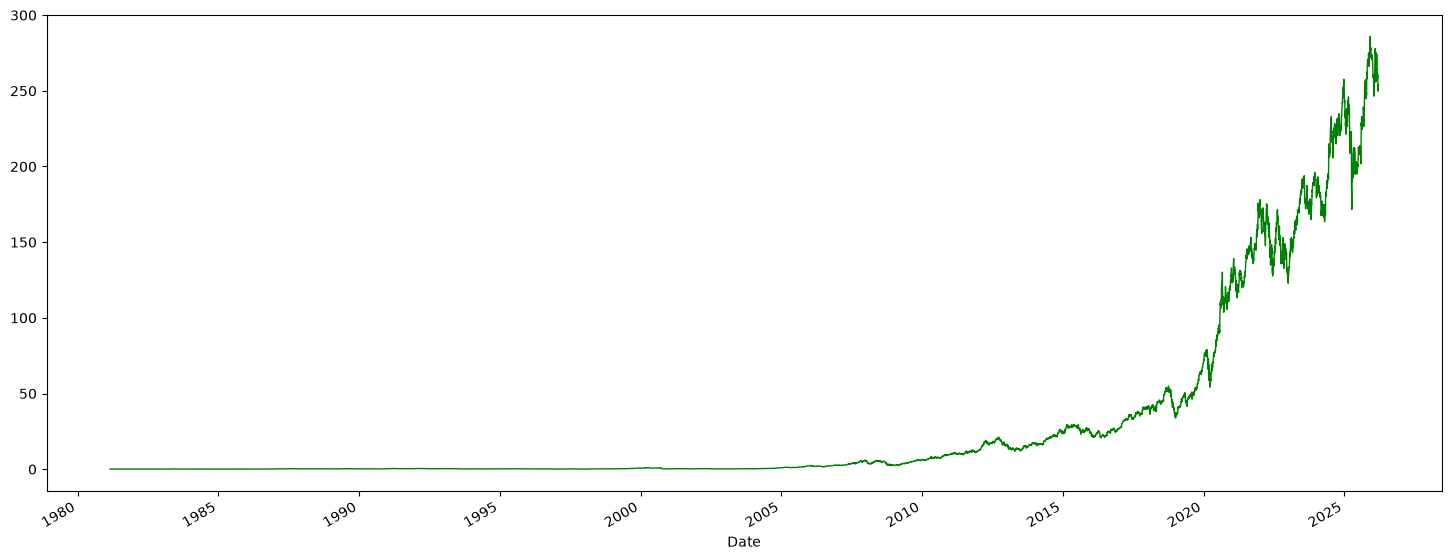

In [19]:
if 'Date' in stocks.columns:
    stocks['Date'] = pd.to_datetime(stocks['Date'])
    stocks = stocks.set_index('Date')
stocks.Close.plot(figsize=(18,7), linewidth=1, c='g')

In [20]:
# Create lagged sequences
window_size = 10

#perm = np.arange(window_size)
perm = np.random.permutation(np.arange(window_size))

X, y = [], []
dates = []
for i in range(len(stocks) - window_size):
    X.append(stocks.iloc[i:i+window_size].values)
    # Predict only the 'close' price (index 1) for y
    y.append(stocks.iloc[i+window_size, 1])
    dates.append(stocks.index[i+window_size])

X = np.array(X)
y = np.array(y)
dates = np.array(dates)

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (11347, 10, 7), y shape: (11347,)


In [21]:
# one temporal split, used by everyone
split_idx    = int(len(X) * 0.8)
X_train_3d   = X[:split_idx]       # for LSTM (3D)
X_test_3d    = X[split_idx:]
X_train_2d   = X_train_3d.reshape(X_train_3d.shape[0], -1)  # for sklearn + Dense
X_test_2d    = X_test_3d.reshape(X_test_3d.shape[0], -1)
y_train      = y[:split_idx]
y_test       = y[split_idx:]
dates_train  = dates[:split_idx]
dates_test   = dates[split_idx:]

print(f"Train: X={X_train_3d.shape}, y={y_train.shape}")
print(f"Test:  X={X_test_3d.shape}, y={y_test.shape}")
print(f"Train: X={X_train_2d.shape}, y={y_train.shape}")
print(f"Test:  X={X_test_2d.shape}, y={y_test.shape}")
print(f"Train: X={dates_train.shape}, y={y_train.shape}")
print(f"Test:  X={dates_test.shape}, y={y_test.shape}")


Train: X=(9077, 10, 7), y=(9077,)
Test:  X=(2270, 10, 7), y=(2270,)
Train: X=(9077, 70), y=(9077,)
Test:  X=(2270, 70), y=(2270,)
Train: X=(9077,), y=(9077,)
Test:  X=(2270,), y=(2270,)


In [22]:
from sklearn.preprocessing import MinMaxScaler
# one scaler, fit on train only, used by Keras pipelines
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled_2d = scaler_X.fit_transform(X_train_2d)
X_test_scaled_2d  = scaler_X.transform(X_test_2d)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1))
# reshape scaled 2D back to 3D
X_train_scaled_3d = X_train_scaled_2d.reshape(X_train_3d.shape)
X_test_scaled_3d  = X_test_scaled_2d.reshape(X_test_3d.shape)

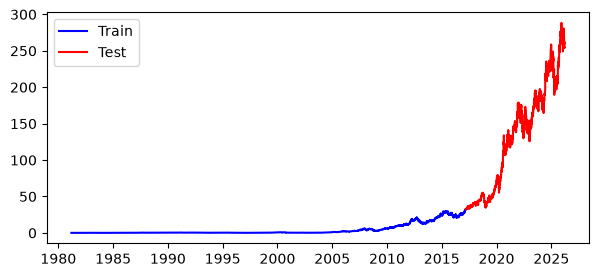

In [23]:
plt.figure(figsize=(7,3))
# y_train and y_test are now 1D arrays
plt.plot( dates_train, y_train, 'b', label='Train' );
plt.plot( dates_test, y_test, 'r', label='Test' );
plt.legend()

In [24]:
'''# Simple index-based split
split_idx = int(len(X) * 0.9)
X_train, y_train, dates_train = X[:split_idx], y[:split_idx], dates[:split_idx]
X_test, y_test, dates_test = X[split_idx:], y[split_idx:], dates[split_idx:]

# Reshape X_train and X_test to be 2D for scikit-learn models
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")'''

'# Simple index-based split\nsplit_idx = int(len(X) * 0.9)\nX_train, y_train, dates_train = X[:split_idx], y[:split_idx], dates[:split_idx]\nX_test, y_test, dates_test = X[split_idx:], y[split_idx:], dates[split_idx:]\n\n# Reshape X_train and X_test to be 2D for scikit-learn models\nX_train = X_train.reshape(X_train.shape[0], -1)\nX_test = X_test.reshape(X_test.shape[0], -1)\n\nprint(f"Train: X={X_train.shape}, y={y_train.shape}")\nprint(f"Test:  X={X_test.shape}, y={y_test.shape}")'

# Cross Validation

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = [
    LinearRegression(),
    KNeighborsRegressor(n_neighbors=4, weights='uniform'),
    RandomForestRegressor(n_estimators=10, max_depth=5),
    RandomForestRegressor(n_estimators=30, max_depth=10),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5),
]

In [26]:
from sklearn.model_selection import cross_val_score, KFold, TimeSeriesSplit

#kf = KFold(n_splits=5, shuffle=True)
kf = TimeSeriesSplit(n_splits=5)

# Reshape X to be 2-dimensional for scikit-learn models
X_2d = X.reshape(X.shape[0], -1)

for m in models:
    print(m)

    cv_scores = -cross_val_score(m, X_2d, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
    cv_scores = pd.DataFrame(cv_scores)
    display(cv_scores.describe().T)

    print()
# end

LinearRegression()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.703848,0.258961,0.378664,0.497069,0.751136,0.941192,0.951179



KNeighborsRegressor(n_neighbors=4)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.681119,0.222503,0.41377,0.477388,0.771587,0.824351,0.918497



RandomForestRegressor(max_depth=5, n_estimators=10)


...

,count,mean,std,min,25%,50%,75%,max
0,5.0,0.326429,0.254118,0.029306,0.071145,0.466199,0.523227,0.542269



GradientBoostingRegressor()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.324486,0.253191,0.029032,0.069355,0.466358,0.514952,0.542734



GradientBoostingRegressor(max_depth=5)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.327433,0.255538,0.029239,0.069953,0.46842,0.526956,0.542598


# Grid SearchCV

In [27]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    )
}

# Define cross-validation strategy
#kf = KFold(n_splits=5, shuffle=True)
kf = TimeSeriesSplit(n_splits=5)

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    grid_search.fit(X_2d, y)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})
# end

results

Performing GridSearchCV for KNeighborsRegressor...
Performing GridSearchCV for RandomForestRegressor...
Performing GridSearchCV for GradientBoostingRegressor...


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-0.6663154674458628),
  'Best Params': {'n_neighbors': 50, 'weights': 'uniform'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.32652293381250147),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 5,
   'min_samples_split': 5,
   'n_estimators': 10}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.32457110105643655),
  'Best Params': {'learning_rate': 0.1,
   'max_depth': 3,
   'min_samples_leaf': 1,
   'n_estimators': 100}}]

# Feature Importance










In [28]:
# Fit a Random Forest model
rf = RandomForestRegressor(n_estimators=1000)
rf.fit(X_2d, y)

# Generate feature names for X_2d
original_features = stocks.columns.tolist()
feature_names_for_X_2d = []
for lag in range(window_size, 0, -1): # Lags from window_size down to 1
    for col in original_features:
        feature_names_for_X_2d.append(f'{col}_lag{lag}')

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=feature_names_for_X_2d).sort_values(ascending=False)
importances = importances[:20]

# Get the names of the selected features
features_rf = importances.index.tolist()

# Create a DataFrame from X_2d with the correct column names for easier slicing
X_2d_df = pd.DataFrame(X_2d, columns=feature_names_for_X_2d)

# Select only the important features from X_2d_df
X_pars = X_2d_df[features_rf]

importances

,0
Close_lag1,0.514465
Low_lag1,0.227773
High_lag1,0.090584
Close_lag2,0.048750
Low_lag2,0.033465
High_lag2,0.015975
Low_lag3,0.013214
Open_lag1,0.011502
Close_lag3,0.010664
Low_lag4,0.006175


# KERAS

In [29]:
!pip install tensorflow

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( X_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=X_train.shape[1]),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dense(1, activation='relu'),
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = X_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model
# end

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [31]:
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Re-defining build_model with the fix for the Input layer
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( X_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])), # Corrected: Input layer now expects 3D shape
        Flatten(), # Added: Flatten the input for Dense layers
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dense(1, activation='linear'), # Changed activation to 'linear' for regression
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = X_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model
# end

epochs                = 500
batch_size            = 256
decay_frac            = 0.8
dropout_rate          = 0.25
initial_learning_rate = 0.01

n_splits = 5
#kf = KFold(n_splits=n_splits, shuffle=True)
kf = TimeSeriesSplit(n_splits=n_splits)

train_mae_list = []
test_mae_list = []
train_r2_list = []
test_r2_list = []

fold = 1
for train_index, test_index in kf.split(X):
    print(f"Fold {fold}/{n_splits}")
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]

    # Scale X_train_fold and y_train_fold for the neural network
    # Flatten X_train_fold and X_test_fold for scaling, then reshape back
    scaler_X = MinMaxScaler(feature_range=(0,1))
    X_train_flat = X_train_fold.reshape(X_train_fold.shape[0], -1)
    X_test_flat = X_test_fold.reshape(X_test_fold.shape[0], -1)

    X_train_scaled = scaler_X.fit_transform(X_train_flat)
    X_test_scaled = scaler_X.transform(X_test_flat)

    X_train_scaled = X_train_scaled.reshape(X_train_fold.shape)
    X_test_scaled = X_test_scaled.reshape(X_test_fold.shape)

    scaler_y = MinMaxScaler(feature_range=(0,1))
    y_train_scaled = scaler_y.fit_transform(y_train_fold.reshape(-1, 1))
    y_test_scaled = scaler_y.transform(y_test_fold.reshape(-1, 1))

    # Build a fresh model (which resets optimizer state including the learning rate schedule)
    model = build_model(
        X_train_scaled, # Changed to X_train_scaled (3D data for current fold)
        epochs,
        batch_size,
        decay_frac,
        initial_learning_rate,
        dropout_rate
    )

    # Early stopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=100,          # Stop after 5 epochs without improvement
        restore_best_weights=True  # Restore the best weights after stopping
    )

    # Train the model
    history = model.fit(
        X_train_scaled, y_train_scaled, # Changed to X_train_scaled (3D data for current fold)
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test_scaled, y_test_scaled), # Changed to X_test_scaled (3D data for current fold)
        verbose=0,
        callbacks=[early_stopping]
    )

    # Evaluate on training data
    y_train_pred_scaled = model.predict(X_train_scaled, verbose=0)
    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled) # Inverse transform predictions
    train_mae = mean_absolute_error(y_train_fold, y_train_pred)
    train_r2 = r2_score(y_train_fold, y_train_pred)

    # Evaluate on test data
    y_test_pred_scaled = model.predict(X_test_scaled, verbose=0)
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled) # Inverse transform predictions
    test_mae = mean_absolute_error(y_test_fold, y_test_pred)
    test_r2 = r2_score(y_test_fold, y_test_pred)

    print("MAE:")
    print(f"  Train: {train_mae:.4f}")
    print(f"  Test:  {test_mae:.4f}")
    print("R^2:")
    print(f"  Train: {train_r2:.4f}")
    print(f"  Test:  {test_r2:.4f}")
    print()

    train_mae_list.append(train_mae)
    test_mae_list.append(test_mae)
    train_r2_list.append(train_r2)
    test_r2_list.append(test_r2)

    fold += 1
# end

Fold 1/5
MAE:
  Train: 0.0294
  Test:  0.0873
R^2:
  Train: 0.7578
  Test:  -0.6776

Fold 2/5
MAE:
  Train: 0.0474
  Test:  0.0771
R^2:
  Train: 0.7444
  Test:  0.7264

Fold 3/5
MAE:
  Train: 0.0587
  Test:  0.5882
R^2:
  Train: 0.7745
  Test:  0.9258

Fold 4/5
MAE:
  Train: 0.3791
  Test:  8.9539
R^2:
  Train: 0.8113
  Test:  0.0193

Fold 5/5
MAE:
  Train: 2.1025
  Test:  42.9251
R^2:
  Train: 0.8435
  Test:  0.4958



In [32]:
'''from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(X_pars, y, dates,
                                                    test_size=0.2, shuffle=False)'''

'from sklearn.model_selection import train_test_split\n\nX_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(X_pars, y, dates,\n                                                    test_size=0.2, shuffle=False)'

In [33]:
'''results_df = pd.DataFrame({
    'Train MAE': train_mae_list,
    'Test MAE': test_mae_list,
    'Train R2': train_r2_list,
    'Test R2': test_r2_list
})

results_df.describe()'''

"results_df = pd.DataFrame({\n    'Train MAE': train_mae_list,\n    'Test MAE': test_mae_list,\n    'Train R2': train_r2_list,\n    'Test R2': test_r2_list\n})\n\nresults_df.describe()"

# Model Creation

In [34]:
dropout_rate = 0.1

model_dense  = Sequential([
    Input(shape=(X_train_scaled_2d.shape[1],)), # Corrected input shape to match X_train_scaled_2d

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),

    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),

    Dense(8, activation='relu'),

    Dense(1, activation='linear'),
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.01)

# Compile model
model_dense .compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

model_dense .summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 32)             │         2,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,041 (11.88 KB)

 Non-trainable params: 96 (384.00 B)

### Re-scaling Data for `model_dense`

The cross-validation loop in `cell_KDvNPcdiepgH` updated the `y_train_scaled` variable. To ensure consistent data cardinality for training `model_dense`, we need to re-scale the data (`X_train_2d`, `y_train`, `X_test_2d`, `y_test`) using the original `scaler_X` and `scaler_y` (fitted on the 80/20 split) immediately before training `model_dense`.

In [35]:
from sklearn.preprocessing import MinMaxScaler

# Re-initialize scalers (or re-use existing ones if already fitted on the correct split)
# scaler_X and scaler_y were defined and fitted in cell 'XlacRcBnxwXz' based on the initial 80/20 split.
# We will re-apply them to ensure consistency.

# Re-scale X_train_2d and X_test_2d
X_train_scaled_2d = scaler_X.transform(X_train_2d)
X_test_scaled_2d  = scaler_X.transform(X_test_2d)

# Re-scale y_train and y_test
y_train_scaled = scaler_y.transform(y_train.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1))

print(f"X_train_scaled_2d shape: {X_train_scaled_2d.shape}")
print(f"y_train_scaled shape: {y_train_scaled.shape}")
print(f"X_test_scaled_2d shape: {X_test_scaled_2d.shape}")
print(f"y_test_scaled shape: {y_test_scaled.shape}")

print("Data for model_dense re-scaled successfully.")

X_train_scaled_2d shape: (9077, 70)
y_train_scaled shape: (9077, 1)
X_test_scaled_2d shape: (2270, 70)
y_test_scaled shape: (2270, 1)
Data for model_dense re-scaled successfully.


In [36]:
X_train_scaled.shape

(9456, 10, 7)

In [37]:
X_test_scaled_2d.shape

(2270, 70)

In [38]:
y_test_scaled.shape

(2270, 1)

In [39]:
y_train_scaled.shape

(9077, 1)

In [40]:
history_dense = model_dense.fit(
    X_train_scaled_2d, y_train_scaled, # Use scaled 2D data
    epochs=150,
    batch_size=64,
    validation_data=(X_test_scaled_2d, y_test_scaled), # Use scaled 2D data for validation
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0794 - val_loss: 0.5046
Epoch 2/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0245 - val_loss: 0.9215
Epoch 3/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0190 - val_loss: 0.1537
Epoch 4/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0193 - val_loss: 0.4358
Epoch 5/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0159 - val_loss: 0.4396
Epoch 6/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0180 - val_loss: 0.3881
Epoch 7/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0168 - val_loss: 0.4814
Epoch 8/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0147 - val_loss: 0.1214
Epoch 9/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0153 - val_loss: 0.1605
Epoch 10/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0143 - val_loss: 0.1214
Epoch 11/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0141 - val_loss: 0.1763
Epoch 12/150
142/142 ━━━━━━━━━━━━━━━━━━━━

284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 564us/step
r2_train:   0.97801
r2_test:    0.99493
rmse_train: 1.1178
rmse_test:  5.1718


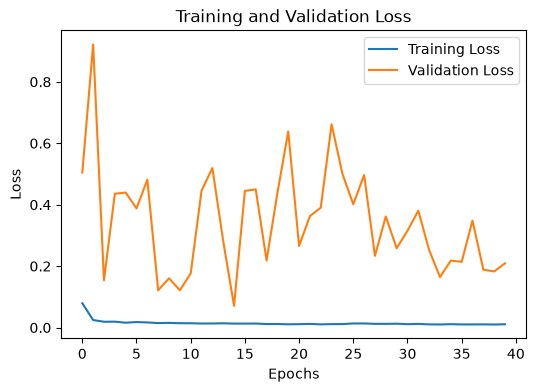

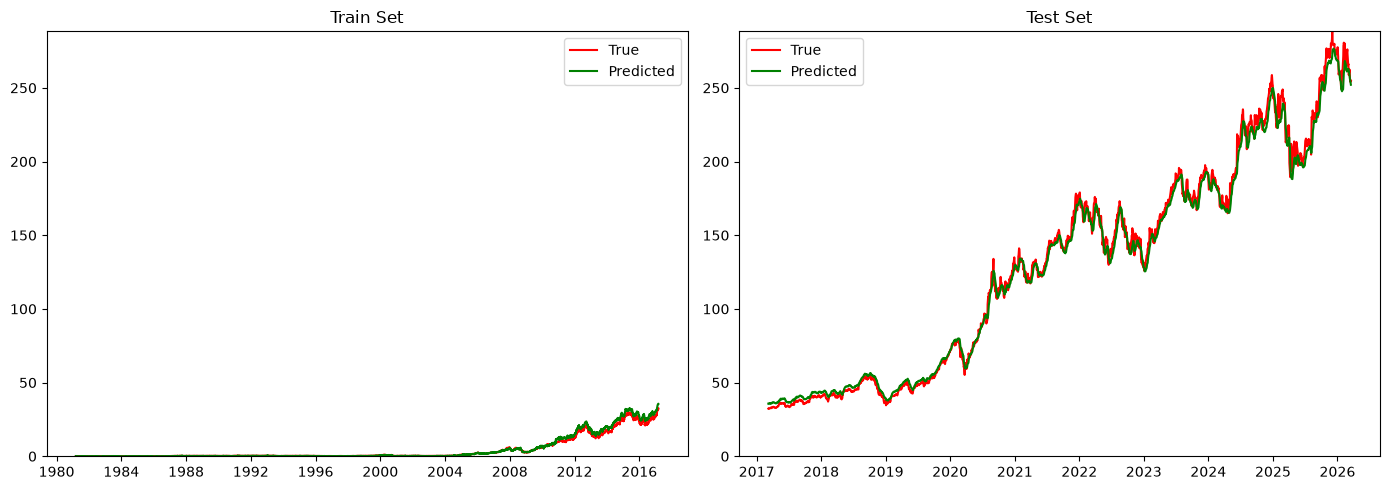

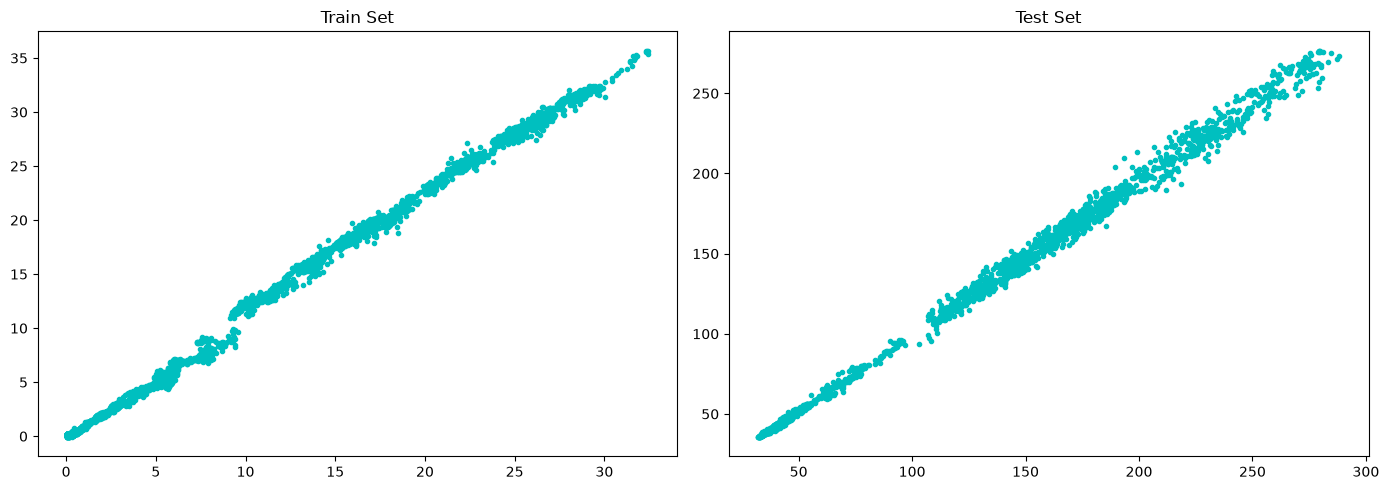

MAE:
  Train: 0.5477
  Test:  3.8402
R^2:
  Train: 0.9780
  Test:  0.9949


In [41]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Get predictions on scaled data
y_train_pred_scaled = model_dense.predict(X_train_scaled_2d)[:,0].reshape(-1, 1)
y_test_pred_scaled  = model_dense.predict(X_test_scaled_2d)[:,0].reshape(-1, 1)

# Inverse transform predictions to original scale
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled).flatten()
y_test_pred  = scaler_y.inverse_transform(y_test_pred_scaled).flatten()

# Define true unscaled values for comparison
y_train_true = y_train
y_test_true = y_test

# Create a figure with two subplots side by side
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Left subplot: Training and Validation Loss
ax.plot(history_dense.history['loss'], label='Training Loss')
ax.plot(history_dense.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()

r2_train = r2_score(y_train_true, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

y_train_pred = pd.Series(y_train_pred, index=dates_train)
y_test_pred  = pd.Series(y_test_pred, index=dates_test)

# Calculate global y-axis limits
y_min = min(y_train_true.min(), y_train_pred.min(), y_test_true.min(), y_test_pred.min())
y_max = max(y_train_true.max(), y_train_pred.max(), y_test_true.max(), y_test_pred.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train, y_train_true, 'r', label='True')
axs[0].plot(y_train_pred, 'g', label='Predicted')
axs[0].set_title('Train Set')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test, y_test_true, 'r', label='True')
axs[1].plot(y_test_pred, 'g', label='Predicted')
axs[1].set_title('Test Set')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_true, y_train_pred.values, 'c.')
axs[0].set_title('Train Set')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test_true, y_test_pred.values, 'c.')
axs[1].set_title('Test Set')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train_true, y_train_pred)
r2_train = r2_score(y_train_true, y_train_pred)
mae_test = mean_absolute_error(y_test_true, y_test_pred)
r2_test = r2_score(y_test_true, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

In [42]:
#! pip install mlflow --ignore-installed blinker

In [43]:
!pip install mlflow cryptography==43.0.3 --ignore-installed blinker

  Using cached mlflow-3.13.0-py3-none-any.whl.metadata (49 kB)
  Using cached cryptography-43.0.3-cp39-abi3-manylinux_2_28_x86_64.whl.metadata (5.4 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cffi-2.0.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.6 kB)
  Using cached mlflow_skinny-3.13.0-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.13.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.5-py3-none-any.whl.metadata (5.4 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached aiohttp-3.14.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.3 kB)
  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached gunicorn-26.0.0-py3-none-any.whl.metadata (5.4 kB)
  Using cached huey

In [110]:
import mlflow
import mlflow.keras
from sklearn.metrics import mean_absolute_error, r2_score

# Set an experiment name
mlflow.set_experiment("Stock Price Prediction - Dense Model")

with mlflow.start_run():
    # Log parameters (you can log any hyperparameter or configuration here)
    mlflow.log_param("epochs", 150)
    mlflow.log_param("batch_size", 64)
    mlflow.log_param("dropout_rate", 0.1)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("loss_function", "mae")

    # Log metrics
    mlflow.log_metric("train_mae", mae_train)
    mlflow.log_metric("test_mae", mae_test)
    mlflow.log_metric("train_r2", r2_train)
    mlflow.log_metric("test_r2", r2_test)

    # Log the Keras model
    mlflow.keras.log_model(model_dense, "dense_model")

    print("MLflow Run completed. View with: !mlflow ui")

2026/06/16 22:52:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 22:52:35 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


MLflow Run completed. View with: !mlflow ui


In [111]:
!mlflow ui

Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
/usr/local/lib/python3.12/dist-packages/mlflow/server/fastapi_app.py:17: StarletteDeprecationWarning: starlette.middleware.wsgi is deprecated and will be removed in a future release. Please refer to https://github.com/abersheeran/a2wsgi as a replacement.
  from starlette.middleware.wsgi import WSGIResponder, build_environ
2026/06/16 22:52:57 ERROR:    [Errno 98] Address already in use


In [45]:
# Install pyngrok to tunnel the MLflow UI
!pip install pyngrok -q

In [46]:
import os
from google.colab import userdata

# Get your ngrok authtoken from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Set the authtoken
!ngrok authtoken {NGROK_AUTH_TOKEN}

print("ngrok authtoken configured.")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
ngrok authtoken configured.


In [113]:
import subprocess
import threading
import time
import os
import socket
from pyngrok import ngrok

MLFLOW_PORT = 5000

def kill_processes_on_port(port):
    """Attempts to kill processes on a given port."""
    print(f"Attempting to kill any process on port {port}...")
    try:
        # Find and kill processes using fuser
        fuser_output = subprocess.run(f"fuser -k {port}/tcp", shell=True, capture_output=True, text=True, check=False)
        if fuser_output.stdout or fuser_output.stderr:
            print(f"fuser output for port {port}:\n{fuser_output.stdout}{fuser_output.stderr}")

        # Find and kill processes using lsof
        lsof_output = subprocess.run(f"lsof -t -i:{port}", shell=True, capture_output=True, text=True, check=False)
        pids = lsof_output.stdout.strip().split('\n')
        pids = [pid for pid in pids if pid.isdigit()]
        if pids:
            print(f"Killing processes {', '.join(pids)} on port {port}...")
            subprocess.run(f"kill -9 {' '.join(pids)}", shell=True, capture_output=True, check=False)
        else:
            print(f"No processes found on port {port} using lsof.")

        print(f"Killed processes on port {port} if any were running.")
        time.sleep(5) # Increased sleep for port release
    except Exception as e:
        print(f"Could not kill process on port {port}: {e}")

def check_port(host, port, timeout=1):
    """Check if a port is open on a given host."""
    try:
        s = socket.create_connection((host, port), timeout=timeout)
        s.close()
        return True
    except (socket.timeout, ConnectionRefusedError):
        return False

def start_mlflow_ui_nohup():
    """Starts MLflow UI as a detached nohup process."""
    # Ensure previous MLflow processes are killed before starting a new one
    # Kill by port
    kill_processes_on_port(5000) # MLflow's default port
    kill_processes_on_port(MLFLOW_PORT) # Our desired port

    # More aggressive kill for any mlflow process
    print("Attempting to kill any 'mlflow' named processes...")
    try:
        # Use pkill -f to kill processes by command name containing 'mlflow'
        pkill_output = subprocess.run("pkill -f mlflow", shell=True, capture_output=True, text=True, check=False)
        if pkill_output.stdout or pkill_output.stderr:
            print(f"pkill output: \n{pkill_output.stdout}{pkill_output.stderr}")
        print("Killed 'mlflow' processes if any were running.")
        time.sleep(5) # Increased sleep for process termination
    except Exception as e:
        print(f"Error attempting to pkill mlflow processes: {e}")

    print(f"Starting MLflow UI using nohup on port {MLFLOW_PORT}...")
    mlflow_command = [
        "nohup", "mlflow", "ui",
        "--host", "0.0.0.0",
        "--port", str(MLFLOW_PORT),
        ">", "mlflow_ui.log", # Redirect stdout to a log file for debugging
        "2>&1", "&" # Redirect stderr to stdout and run in background
    ]
    # Execute as a single shell command string to use nohup and '&' correctly
    subprocess.Popen(" ".join(mlflow_command), shell=True, preexec_fn=os.setsid)
    print("MLflow UI process initiated with nohup. Waiting for it to become ready...")

    # Wait for MLflow UI to start and listen on the specified port
    max_retries = 60 # Increased retries to allow more time for startup
    for i in range(max_retries):
        print(f"Waiting for MLflow UI to be ready on port {MLFLOW_PORT}... (Attempt {i+1}/{max_retries})")
        if check_port('127.0.0.1', MLFLOW_PORT):
            print(f"MLflow UI is now listening on port {MLFLOW_PORT}.")
            return True # Indicate successful startup
        time.sleep(5) # Wait longer between checks

    print(f"MLflow UI did not become ready on port {MLFLOW_PORT} within the expected time.")
    # Log content of mlflow_ui.log for debugging purposes
    if os.path.exists("mlflow_ui.log"):
        with open("mlflow_ui.log", "r") as f:
            print("--- MLflow UI Log Start ---")
            print(f.read())
            print("--- MLflow UI Log End ---")
    raise RuntimeError(f"MLflow UI failed to start and listen on port {MLFLOW_PORT}.")

# Start MLflow UI
try:
    start_mlflow_ui_nohup()
except RuntimeError as e:
    print(e)
    # If MLflow UI fails to start, print error and exit gracefully from the cell
    # without attempting ngrok connection.
    exit() # Exit the cell execution if MLflow UI fails to start

# Give MLflow a bit more time after port check, just in case
time.sleep(20) # Increased delay

# Create a public URL for the MLflow UI using ngrok
print("Creating ngrok tunnel...")
# Ensure any previous ngrok tunnels are disconnected to avoid conflicts
ngrok.kill()

public_url = None
# Retry ngrok connection a few times as it can sometimes fail on first attempt
# Also, check if MLflow UI is still alive within this loop
for i in range(10): # Increased ngrok retries for stability
    try:
        # Check if MLflow UI is still running before attempting ngrok connect
        if not check_port('127.0.0.1', MLFLOW_PORT):
            print("MLflow UI process appears to have died. Exiting ngrok tunnel creation.")
            raise RuntimeError("MLflow UI process died.")

        public_url = ngrok.connect(MLFLOW_PORT, pyngrok_config=ngrok.conf.PyngrokConfig(api_key=os.environ.get('NGROK_AUTH_TOKEN')))
        print(f"MLflow UI is available at: {public_url}")
        time.sleep(15) # Increased delay after successful ngrok connection for more stability
        break
    except Exception as e:
        print(f"ngrok connection failed (Attempt {i+1}/10): {e}")
        time.sleep(20) # Increased wait before retrying ngrok (increased for stability)

if public_url is None:
    print("Failed to establish ngrok tunnel after multiple attempts.")


Attempting to kill any process on port 5000...
fuser output for port 5000:
 984931 985045 985046 985047 9850485000/tcp:           

No processes found on port 5000 using lsof.
Killed processes on port 5000 if any were running.
Attempting to kill any process on port 5000...
No processes found on port 5000 using lsof.
Killed processes on port 5000 if any were running.
Attempting to kill any 'mlflow' named processes...
Killed 'mlflow' processes if any were running.
Starting MLflow UI using nohup on port 5000...
MLflow UI process initiated with nohup. Waiting for it to become ready...
Waiting for MLflow UI to be ready on port 5000... (Attempt 1/60)
Waiting for MLflow UI to be ready on port 5000... (Attempt 2/60)
Waiting for MLflow UI to be ready on port 5000... (Attempt 3/60)
MLflow UI is now listening on port 5000.
Creating ngrok tunnel...
MLflow UI is available at: NgrokTunnel: "https://army-repossess-ashen.ngrok-free.dev" -> "http://localhost:5000"


In [109]:
print('Checking active processes on port 8000:')
!lsof -i :5000
# If lsof is not installed, you can try:
!netstat -tuln | grep 5000
!fuser 5000/tcp

Checking active processes on port 8000:
COMMAND    PID USER   FD   TYPE  DEVICE SIZE/OFF NODE NAME
python3 980586 root    3u  IPv4 2896288      0t0  TCP *:5000 (LISTEN)
python3 980700 root    3u  IPv4 2896288      0t0  TCP *:5000 (LISTEN)
python3 980701 root    3u  IPv4 2896288      0t0  TCP *:5000 (LISTEN)
python3 980702 root    3u  IPv4 2896288      0t0  TCP *:5000 (LISTEN)
python3 980703 root    3u  IPv4 2896288      0t0  TCP *:5000 (LISTEN)
tcp        0      0 0.0.0.0:5000            0.0.0.0:*               LISTEN     
5000/tcp:            980586 980700 980701 980702 980703


The MLflow UI should now be running and accessible via the ngrok tunnel provided in the output above. Please check the output from the previous cell for the latest URL.

### Alternative: Viewing MLflow UI with `localtunnel`

Since `ngrok` requires an authenticated token, we can use `localtunnel` as an alternative. `localtunnel` can also expose your local MLflow UI to a public URL, often without requiring explicit authentication for basic use.


# LSTM

In [48]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay

# define training parameters
epochs          = 500
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train_3d.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.05

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

In [49]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

In [50]:
# is this scaled
X_train_2 = X_train_3d # X_train_3d is already in the correct 3D shape (samples, timesteps, features)
X_test_2 = X_test_3d   # X_test_3d is already in the correct 3D shape (samples, timesteps, features)

# Determine the number of features from X_train_3d's last dimension
num_features = X_train_3d.shape[2]

model_lstm = Sequential([
    # The input shape for LSTM layers should be (timesteps, features)
    Input(shape=(window_size, num_features)),

    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.001)

# Compile model
model_lstm.compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 25 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

model_lstm.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,193 (125.75 KB)

 Trainable params: 32,065 (125.25 KB)

 Non-trainable params: 128 (512.00 B)

In [51]:
X_train_scaled_3d.shape

(9077, 10, 7)

In [52]:
history_lstm = model_lstm.fit(
    X_train_scaled_3d, y_train_scaled, # Use scaled 3D data
    epochs=150,
    batch_size=64,
    validation_data=(X_test_scaled_3d, y_test_scaled), # Use scaled 3D data for validation
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/150
Checking for MLflow UI availability...
 32/142 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0966Checking for MLflow UI availability...
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0391 - val_loss: 2.0533
Epoch 2/150
139/142 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0184Checking for MLflow UI availability...
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0167 - val_loss: 1.9673
Epoch 3/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0128 - val_loss: 1.9098
Epoch 4/150
137/142 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0112Checking for MLflow UI availability...
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0106 - val_loss: 1.9607
Epoch 5/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0106 - val_loss: 1.8287
Epoch 6/150
122/142 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0092Checking for MLflow UI availability...
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0091 - val_loss: 1.8534
Epoch 7/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.

  1/284 ━━━━━━━━━━━━━━━━━━━━ 42s 149ms/stepChecking for MLflow UI availability...
284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


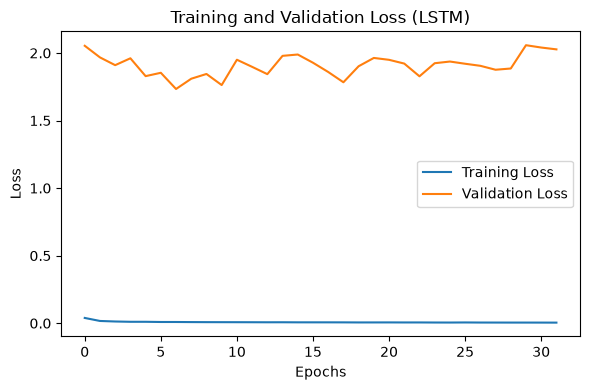

r2_train:   0.99023
r2_test:    -1.5931
rmse_train: 0.74518
rmse_test:  116.93


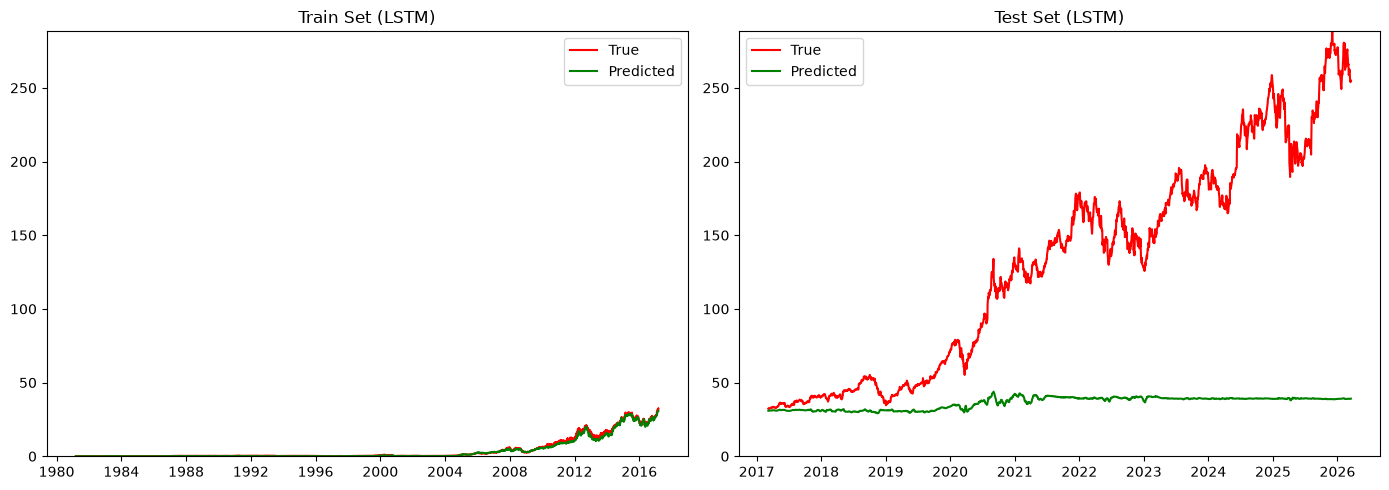

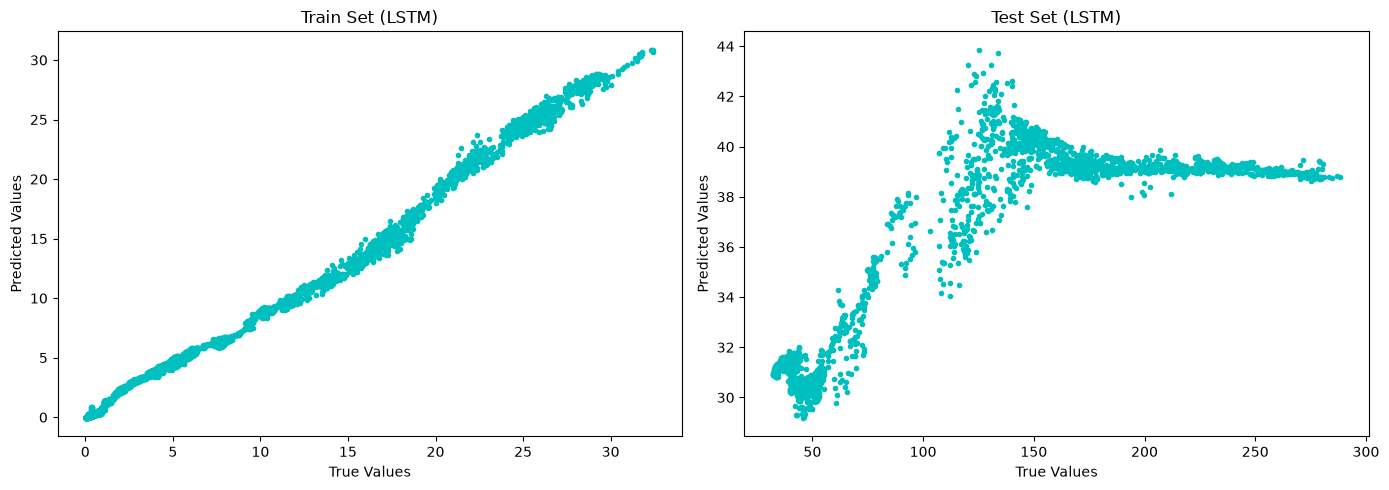

MAE:
  Train: 0.4264
  Test:  94.1542
R^2:
  Train: 0.9902
  Test:  -1.5931


In [53]:
# Get predictions on scaled data
y_train_pred_scaled = model_lstm.predict(X_train_scaled_3d)[:,0].reshape(-1, 1)
y_test_pred_scaled  = model_lstm.predict(X_test_scaled_3d)[:,0].reshape(-1, 1)

# Inverse transform predictions to original scale
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled).flatten()
y_test_pred  = scaler_y.inverse_transform(y_test_pred_scaled).flatten()

# Now use the true values and dates from the train_test_split
y_train_true = y_train
y_test_true = y_test
dates_train_plot = dates_train
dates_test_plot = dates_test

# Create a figure with one subplot for loss
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot Training and Validation Loss
ax.plot(history_lstm.history['loss'], label='Training Loss')
ax.plot(history_lstm.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss (LSTM)')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Calculate metrics for LSTM model
r2_train = r2_score(y_train_true, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

# Convert predictions to pandas Series with dates as index for plotting
y_train_pred_series = pd.Series(y_train_pred.flatten(), index=dates_train_plot)
y_test_pred_series  = pd.Series(y_test_pred.flatten(), index=dates_test_plot)

# Calculate global y-axis limits for consistent plotting
y_min = min(y_train_true.min(), y_train_pred_series.min(), y_test_true.min(), y_test_pred_series.min())
y_max = max(y_train_true.max(), y_train_pred_series.max(), y_test_true.max(), y_test_pred_series.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_plot, y_train_true, 'r', label='True')
axs[0].plot(y_train_pred_series, 'g', label='Predicted')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test_plot, y_test_true, 'r', label='True')
axs[1].plot(y_test_pred_series, 'g', label='Predicted')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot scatter plots for train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_true, y_train_pred_series.values, 'c.')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test_true, y_test_pred_series.values, 'c.')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train_true, y_train_pred)
mae_test = mean_absolute_error(y_test_true, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

In [54]:
# Create a DataFrame to organize the data of true vs pred data graph
predicted_results_df_corrected = pd.DataFrame({
    'Actual Close Price': pd.Series(y_test_true, index=dates_test_plot), # Use y_test_true and dates_test_plot
    'Predicted Stock Price': pd.Series(y_test_pred, index=dates_test_plot),
    'Difference (Error)': (pd.Series(y_test_true, index=dates_test_plot) - pd.Series(y_test_pred, index=dates_test_plot)),
    'Percentage Error (%)': ((abs(pd.Series(y_test_true, index=dates_test_plot) - pd.Series(y_test_pred, index=dates_test_plot))) / pd.Series(y_test_true, index=dates_test_plot)) * 100
})

# Get the original 'Open' prices from the stocks DataFrame using dates_test_plot's index
# Note: 'stocks' DataFrame has 'Open' (capital O) column
open_prices = stocks.loc[dates_test_plot, ['Open']]

# Merge this information into predicted_results_df, aligning by index
predicted_results_df_corrected = predicted_results_df_corrected.merge(open_prices, left_index=True, right_index=True)

# Reorder columns for clarity, putting 'Open' and 'Actual Close Price' first
predicted_results_df_corrected = predicted_results_df_corrected[[
    'Open', 'Actual Close Price', 'Predicted Stock Price',
    'Difference (Error)', 'Percentage Error (%)'
]]

# Sort the DataFrame by its index (dates) to enable proper time-series slicing
predicted_results_df_corrected = predicted_results_df_corrected.sort_index()

# Display the corrected numerical table filtered from 2007 to 2026
display(predicted_results_df_corrected.loc['2025':'2026'])

,Open,Actual Close Price,Predicted Stock Price,Difference (Error),Percentage Error (%)
2025-01-02,247.577549,247.746638,38.912525,208.834113,84.293420
2025-01-03,242.037811,242.853348,38.981415,203.871933,83.948578
2025-01-06,242.982661,245.986258,39.017670,206.968588,84.138273
2025-01-07,241.659879,244.215924,38.931858,205.284065,84.058428
2025-01-08,240.605648,242.385931,38.952576,203.433355,83.929523
...,...,...,...,...,...
2026-03-12,258.660004,258.950012,38.949303,220.000710,84.958756
2026-03-13,255.479996,256.329987,39.038509,217.291477,84.770214
2026-03-16,252.110001,253.889999,39.008858,214.881142,84.635528
2026-03-17,252.960007,255.130005,39.057289,216.072716,84.691221


### What is MLflow?

MLflow is an open-source platform for managing the end-to-end machine learning lifecycle. It addresses four primary functions:

1.  **Tracking:** Record and query experiments (code, data, configuration, results).
2.  **Projects:** Package ML code in a reusable, reproducible form.
3.  **Models:** Manage ML models from various libraries and deploy them to diverse serving platforms.
4.  **Model Registry:** Store, annotate, discover, and manage models in a central repository.

To view the MLflow UI, you would typically run `!mlflow ui` in your terminal or a separate Colab cell if you have a local setup or a tracking server. In Colab, if you want to run `mlflow ui` within the notebook, you would typically need to expose a port, which is a bit more involved. For now, the focus is on logging.

### What is DVC?

DVC (Data Version Control) is an open-source version control system for machine learning projects. It makes ML projects reproducible by tracking machine learning models and datasets. DVC works alongside Git, allowing you to manage large files and directories as part of your Git repository without committing them directly to Git.

Key features include:

1.  **Data Versioning:** Version large datasets and models.
2.  **Experiment Management:** Track experiments by linking code, data, and models.
3.  **Reproducibility:** Recreate experiments by checking out specific data and model versions.
4.  **Pipeline Management:** Define and run data processing and ML pipelines.

#Gemini Suggestion and my fix

### Scaling Data for LSTM Training

The previous LSTM model was trained on unscaled data. It's crucial for neural networks like LSTMs to train on scaled data for better convergence and performance. We will now apply `MinMaxScaler` to the training and testing sets of `X` and `y` that were derived from the feature-selected data (`X_pars`).

The `scaler_X_final` will be fitted on the 2D `X_train` (before reshaping to 3D for LSTM) and `scaler_y_final` will be fitted on `y_train`. These scalers will then be used to transform both the training and testing sets.

In [55]:
recent_stocks = stocks.tail(574)
recent_stocks

,Open,High,Low,Close,Volume,Moving_Average,RSI
Date,,,,,,,
2023-12-01,188.373065,189.590414,187.284369,189.273712,45704800,177.446822,67.053646
2023-12-04,188.026663,188.095951,185.522677,187.482315,43389500,177.741163,61.115171
2023-12-05,188.254333,192.401240,188.224627,191.431320,66628400,178.088983,67.841875
2023-12-06,192.450710,192.757521,190.134773,190.342621,41089700,178.496475,64.543803
2023-12-07,191.639164,192.995073,191.599567,192.272583,47477700,178.972812,67.540913
...,...,...,...,...,...,...,...
2026-03-12,258.660004,258.950012,254.179993,255.759995,40794000,263.034650,40.400334
2026-03-13,255.479996,256.329987,249.520004,250.119995,36930000,262.580556,35.468931
2026-03-16,252.110001,253.889999,249.880005,252.820007,32074200,262.204839,39.271095


### If it doesnt work run lstm in new notebook

In [56]:
# Create lagged sequences
window_size = 10

#perm = np.arange(window_size)
perm = np.random.permutation(np.arange(window_size))

X_recent, y_recent = [], []
dates_recent = []
for i in range(len(recent_stocks) - window_size):
    X_recent.append(recent_stocks.iloc[i:i+window_size].values)
    # Predict only the 'close' price (index 1) for y
    y_recent.append(recent_stocks.iloc[i+window_size, 1])
    dates_recent.append(recent_stocks.index[i+window_size])

X_recent = np.array(X_recent)
y_recent = np.array(y_recent)
dates_recent = np.array(dates_recent)

print(f"X shape: {X_recent.shape}, y shape: {y_recent.shape}")

X shape: (564, 10, 7), y shape: (564,)


In [57]:
'''# Simple index-based split
split_idx = int(len(X_recent) * 0.9)
X_train_recent, y_train_recent, dates_recent_train = X_recent[:split_idx], y_recent[:split_idx], dates_recent[:split_idx]
X_test_recent, y_test_recent, dates_test_recent = X_recent[split_idx:], y_recent[split_idx:], dates_recent[split_idx:]

# Reshape X_train and X_test to be 2D for scikit-learn models
X_train_recent = X_train_recent.reshape(X_train_recent.shape[0], -1)
X_test_recent = X_test_recent.reshape(X_test_recent.shape[0], -1)

print(f"Train: X={X_train_recent.shape}, y={y_train_recent.shape}")
print(f"Test:  X={X_test_recent.shape}, y={y_test_recent.shape}")'''

'# Simple index-based split\nsplit_idx = int(len(X_recent) * 0.9)\nX_train_recent, y_train_recent, dates_recent_train = X_recent[:split_idx], y_recent[:split_idx], dates_recent[:split_idx]\nX_test_recent, y_test_recent, dates_test_recent = X_recent[split_idx:], y_recent[split_idx:], dates_recent[split_idx:]\n\n# Reshape X_train and X_test to be 2D for scikit-learn models\nX_train_recent = X_train_recent.reshape(X_train_recent.shape[0], -1)\nX_test_recent = X_test_recent.reshape(X_test_recent.shape[0], -1)\n\nprint(f"Train: X={X_train_recent.shape}, y={y_train_recent.shape}")\nprint(f"Test:  X={X_test_recent.shape}, y={y_test_recent.shape}")'

In [58]:
'''from sklearn.preprocessing import MinMaxScaler
import joblib # For saving/loading scalers

# Initialize scalers
scaler_X_final = MinMaxScaler(feature_range=(0, 1))
scaler_y_final = MinMaxScaler(feature_range=(0, 1))

# Fit and transform X_train and X_test
# Note: X_train and X_test are currently 2D from FTH25CdEe2Sm
X_train_scaled_2d = scaler_X_final.fit_transform(X_train_recent)
X_test_scaled_2d = scaler_X_final.transform(X_test_recent)

# Fit and transform y_train and y_test
y_train_scaled = scaler_y_final.fit_transform(y_train_recent.reshape(-1, 1))
y_test_scaled = scaler_y_final.transform(y_test_recent.reshape(-1, 1))

print("Data scaled successfully.")

# Reshape the scaled X data into 3D for LSTM input
window_size = 10 # This should be consistent with how X was created in DrO4kslNboUk
num_features = X_train_scaled_2d.shape[1] // window_size # Number of original features

X_train_scaled_3d = X_train_scaled_2d.reshape((X_train_scaled_2d.shape[0], window_size, num_features))
X_test_scaled_3d = X_test_scaled_2d.reshape((X_test_scaled_2d.shape[0], window_size, num_features))

print(f"Reshaped X_train_scaled_3d shape: {X_train_scaled_3d.shape}")
print(f"Reshaped X_test_scaled_3d shape: {X_test_scaled_3d.shape}")'''

'from sklearn.preprocessing import MinMaxScaler\nimport joblib # For saving/loading scalers\n\n# Initialize scalers\nscaler_X_final = MinMaxScaler(feature_range=(0, 1))\nscaler_y_final = MinMaxScaler(feature_range=(0, 1))\n\n# Fit and transform X_train and X_test\n# Note: X_train and X_test are currently 2D from FTH25CdEe2Sm\nX_train_scaled_2d = scaler_X_final.fit_transform(X_train_recent)\nX_test_scaled_2d = scaler_X_final.transform(X_test_recent)\n\n# Fit and transform y_train and y_test\ny_train_scaled = scaler_y_final.fit_transform(y_train_recent.reshape(-1, 1))\ny_test_scaled = scaler_y_final.transform(y_test_recent.reshape(-1, 1))\n\nprint("Data scaled successfully.")\n\n# Reshape the scaled X data into 3D for LSTM input\nwindow_size = 10 # This should be consistent with how X was created in DrO4kslNboUk\nnum_features = X_train_scaled_2d.shape[1] // window_size # Number of original features\n\nX_train_scaled_3d = X_train_scaled_2d.reshape((X_train_scaled_2d.shape[0], window_size,

### Time Series Cross-Validation for LSTM Model

This provide a more robust evaluation of the model's performance across different time periods, similar to how other models were evaluated.

In [59]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Define the LSTM model building function for cross-validation
def build_lstm_model_cv(window_size, num_features, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(window_size, num_features)),
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),
        BatchNormalization(),
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# Assuming X_recent and y_recent are already defined and represent the data to be used
# X_recent has shape (n_samples, window_size, n_features)
# y_recent has shape (n_samples,)

# Define cross-validation parameters
n_splits = 5
kf_time_series = TimeSeriesSplit(n_splits=n_splits)

epochs = 150 # adjust this
batch_size = 64 # adjust this

train_mae_cv_list = []
test_mae_cv_list = []
train_r2_cv_list = []
test_r2_cv_list = []

fold = 1
# X_recent and y_recent are 3D and 1D respectively, but TimeSeriesSplit expects 2D array for X
# We will use X_recent_2d and reshape within the loop for LSTM input

# First, reshape X_recent to 2D for TimeSeriesSplit
X_recent_2d = X_recent.reshape(X_recent.shape[0], -1)

for train_index, test_index in kf_time_series.split(X_recent_2d):
    print(f"Fold {fold}/{n_splits}")

    # Split data for the current fold
    X_train_fold_2d, X_test_fold_2d = X_recent_2d[train_index], X_recent_2d[test_index]
    y_train_fold, y_test_fold = y_recent[train_index], y_recent[test_index]

    # Scale X and y within the fold to prevent data leakage
    scaler_X_cv = MinMaxScaler(feature_range=(0, 1))
    scaler_y_cv = MinMaxScaler(feature_range=(0, 1))

    X_train_scaled_2d = scaler_X_cv.fit_transform(X_train_fold_2d)
    X_test_scaled_2d = scaler_X_cv.transform(X_test_fold_2d)

    y_train_scaled = scaler_y_cv.fit_transform(y_train_fold.reshape(-1, 1))
    y_test_scaled = scaler_y_cv.transform(y_test_fold.reshape(-1, 1))

    # Reshape scaled X data to 3D for LSTM input
    current_window_size = X_recent.shape[1] # This should be 10
    current_num_features = X_recent.shape[2] # This should be 5

    X_train_scaled_3d_cv = X_train_scaled_2d.reshape((X_train_scaled_2d.shape[0], current_window_size, current_num_features))
    X_test_scaled_3d_cv = X_test_scaled_2d.reshape((X_test_scaled_2d.shape[0], current_window_size, current_num_features))

    # Build a fresh LSTM model for each fold
    model_lstm_cv = build_lstm_model_cv(current_window_size, current_num_features)

    # Early stopping callback
    early_stopping_cv = EarlyStopping(
        monitor='val_loss',
        patience=25, # Adjusted patience for cross-validation
        restore_best_weights=True
    )

    # Train the model
    history_cv = model_lstm_cv.fit(
        X_train_scaled_3d_cv, y_train_scaled,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test_scaled_3d_cv, y_test_scaled),
        verbose=0,
        callbacks=[early_stopping_cv]
    )

    # Evaluate on training data
    y_train_pred_scaled_cv = model_lstm_cv.predict(X_train_scaled_3d_cv, verbose=0)
    y_train_pred_cv = scaler_y_cv.inverse_transform(y_train_pred_scaled_cv) # Inverse transform predictions
    train_mae_cv = mean_absolute_error(y_train_fold, y_train_pred_cv)
    train_r2_cv = r2_score(y_train_fold, y_train_pred_cv)

    # Evaluate on test data
    y_test_pred_scaled_cv = model_lstm_cv.predict(X_test_scaled_3d_cv, verbose=0)
    y_test_pred_cv = scaler_y_cv.inverse_transform(y_test_pred_scaled_cv) # Inverse transform predictions
    test_mae_cv = mean_absolute_error(y_test_fold, y_test_pred_cv)
    test_r2_cv = r2_score(y_test_fold, y_test_pred_cv)

    print("MAE:")
    print(f"  Train: {train_mae_cv:.4f}")
    print(f"  Test:  {test_mae_cv:.4f}")
    print("R^2:")
    print(f"  Train: {train_r2_cv:.4f}")
    print(f"  Test:  {test_r2_cv:.4f}")
    print()

    train_mae_cv_list.append(train_mae_cv)
    test_mae_cv_list.append(test_mae_cv)
    train_r2_cv_list.append(train_r2_cv)
    test_r2_cv_list.append(test_r2_cv)

    fold += 1
# end

print("\nCross-validation results:")
cv_results_df = pd.DataFrame({
    'Train MAE': train_mae_cv_list,
    'Test MAE': test_mae_cv_list,
    'Train R2': train_r2_cv_list,
    'Test R2': test_r2_cv_list
})
display(cv_results_df)
display(cv_results_df.describe())

Fold 1/5
Checking for MLflow UI availability...
Checking for MLflow UI availability...
Checking for MLflow UI availability...
Checking for MLflow UI availability...
Checking for MLflow UI availability...
Checking for MLflow UI availability...
MAE:
  Train: 3.6658
  Test:  24.1652
R^2:
  Train: 0.7104
  Test:  -1.7462

Fold 2/5
Checking for MLflow UI availability...
Checking for MLflow UI availability...
MLflow UI should be running locally now.
MAE:
  Train: 5.2567
  Test:  12.6938
R^2:
  Train: 0.8939
  Test:  -1.2196

Fold 3/5
MAE:
  Train: 3.7184
  Test:  5.1418
R^2:
  Train: 0.9640
  Test:  0.8212

Fold 4/5
MAE:
  Train: 3.6065
  Test:  8.2038
R^2:
  Train: 0.9619
  Test:  0.7662

Fold 5/5
MAE:
  Train: 3.1133
  Test:  2.7798
R^2:
  Train: 0.9706
  Test:  0.8408


Cross-validation results:


,Train MAE,Test MAE,Train R2,Test R2
0,3.665800,24.165198,0.710426,-1.746202
1,5.256670,12.693844,0.893924,-1.219644
2,3.718379,5.141791,0.964002,0.821199
3,3.606489,8.203826,0.961882,0.766204
4,3.113311,2.779837,0.970605,0.840831


,Train MAE,Test MAE,Train R2,Test R2
count,5.000000,5.000000,5.000000,5.000000
mean,3.872130,10.596899,0.900168,-0.107522
std,0.810792,8.442265,0.110551,1.269584
min,3.113311,2.779837,0.710426,-1.746202
25%,3.606489,5.141791,0.893924,-1.219644
50%,3.665800,8.203826,0.961882,0.766204
75%,3.718379,12.693844,0.964002,0.821199
max,5.256670,24.165198,0.970605,0.840831


In [60]:
#X_train_scaled_3d_cv.shape

In [61]:
#y_train_pred_cv.shape

In [62]:
#X_train_scaled_3d.shape

In [63]:
#y_train_pred.shape

In [64]:
#y_train_recent.shape

In [65]:
'''from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(X_recent, y_recent, dates_recent,
                                                    test_size=0.2, random_state=42)'''

'from sklearn.model_selection import train_test_split\n\nX_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(X_recent, y_recent, dates_recent,\n                                                    test_size=0.2, random_state=42)'

In [66]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input

# define training parameters
epochs          = 250
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train_3d.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.001 # Changed from 0.05 to 0.001 to match CV setup

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define model_lstm_final (moved from a later cell)
window_size = 10 # Assuming this is consistent
num_features = X_train_3d.shape[2] # Corrected: Derive num_features from the actual number of features

model_lstm_final = Sequential([
    Input(shape=(window_size, num_features)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model_lstm_final.compile(
    optimizer=optimizer,
    loss='mae'
)

In [67]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

### Retraining LSTM Model with Scaled Data

Now we will define and retrain the LSTM model using the newly scaled `X_train_scaled_3d` and `y_train_scaled` data. We will use the same architecture and early stopping mechanism as before. After training, we will evaluate its performance.

In [68]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Correctly determine the number of features from the scaled 3D data
num_features = X_train_scaled_3d_cv.shape[2]

# Define the LSTM model with the same architecture as before
model_lstm_final = Sequential([
    Input(shape=(window_size, num_features)), # Use the correctly calculated num_features

    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer and compile the model
optimizer = Adam(learning_rate=0.001) # Use the same learning rate as previous LSTM
model_lstm_final.compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 25 epochs without improvement (consistent with previous)
    restore_best_weights=True  # Restore the best weights after stopping
)

model_lstm_final.summary()

# --- Start of added check for data cardinality ---
#print(f"Checking X_train_scaled_3d shape: {X_train_scaled_3d_cv.shape}")
#print(f"Checking y_train_scaled shape: {y_train_scaled.shape}")

#if X_train_scaled_3d.shape[0] != y_train_scaled.shape[0]:
#    raise ValueError(f"Data cardinality mismatch: X_train has {X_train_scaled_3d.shape[0]} samples, but y_train has {y_train_scaled.shape[0]} samples.")
# --- End of added check for data cardinality ---

# Initialize and fit scaler_y_final with the unscaled y_train_fold from the last CV fold
scaler_y_final = MinMaxScaler(feature_range=(0, 1))
scaler_y_final.fit(y_train_fold.reshape(-1, 1))

# Train the model with scaled data
history_lstm_final = model_lstm_final.fit(
    X_train_scaled_3d_cv, y_train_scaled,
    epochs=250, # Use same number of epochs
    batch_size=64, # Reverting batch size as per user's preference
    validation_data=(X_test_scaled_3d_cv, y_test_scaled),
    verbose=1,
    callbacks=[early_stopping]
)

# Get predictions using the final model
y_train_pred_scaled = model_lstm_final.predict(X_train_scaled_3d_cv)
y_test_pred_scaled  = model_lstm_final.predict(X_test_scaled_3d_cv)

# Inverse transform predictions to original scale
y_train_pred = scaler_y_final.inverse_transform(y_train_pred_scaled)
y_test_pred  = scaler_y_final.inverse_transform(y_test_pred_scaled)

# Inverse transform true values for consistent comparison based on the cv fold
y_train_true_original = y_train_fold
y_test_true_original = y_test_fold

# Calculate metrics for the retrained LSTM model
r2_train = r2_score(y_train_true_original, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true_original, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true_original, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true_original, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 10, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,193 (125.75 KB)

 Trainable params: 32,065 (125.25 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.2000 - val_loss: 0.5988
Epoch 2/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1477 - val_loss: 0.5998
Epoch 3/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1200 - val_loss: 0.5792
Epoch 4/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1137 - val_loss: 0.5838
Epoch 5/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1063 - val_loss: 0.5364
Epoch 6/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0973 - val_loss: 0.5218
Epoch 7/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0987 - val_loss: 0.5116
Epoch 8/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0878 - val_loss: 0.5247
Epoch 9/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0813 - val_loss: 0.5280
Epoch 10/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0814 - val_loss: 0.5493
Epoch 11/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0788 - val_loss: 0.5391
Epoch 12/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0849 - val_lo

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


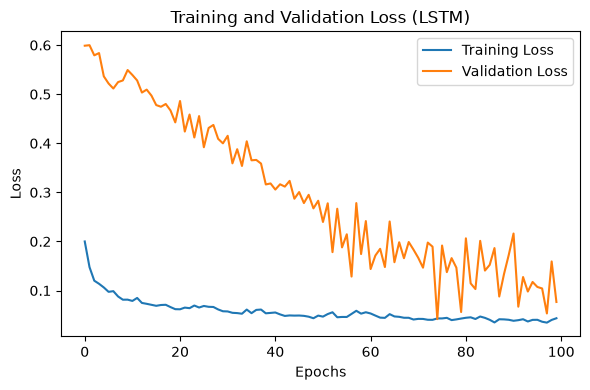

r2_train:   0.96809
r2_test:    0.59162
rmse_train: 4.4327
rmse_test:  5.6552


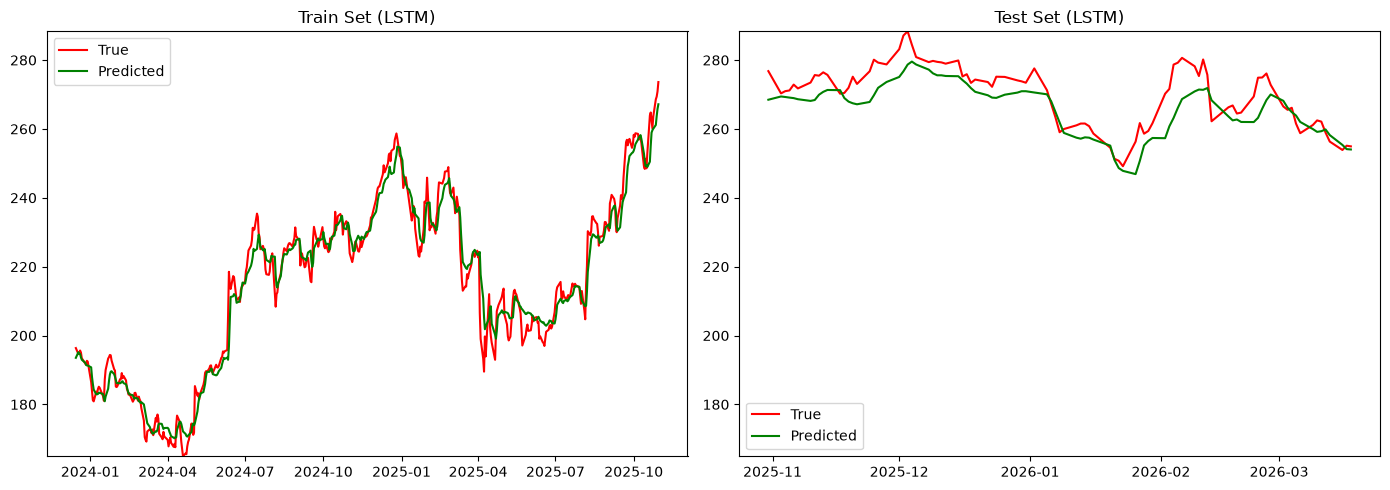

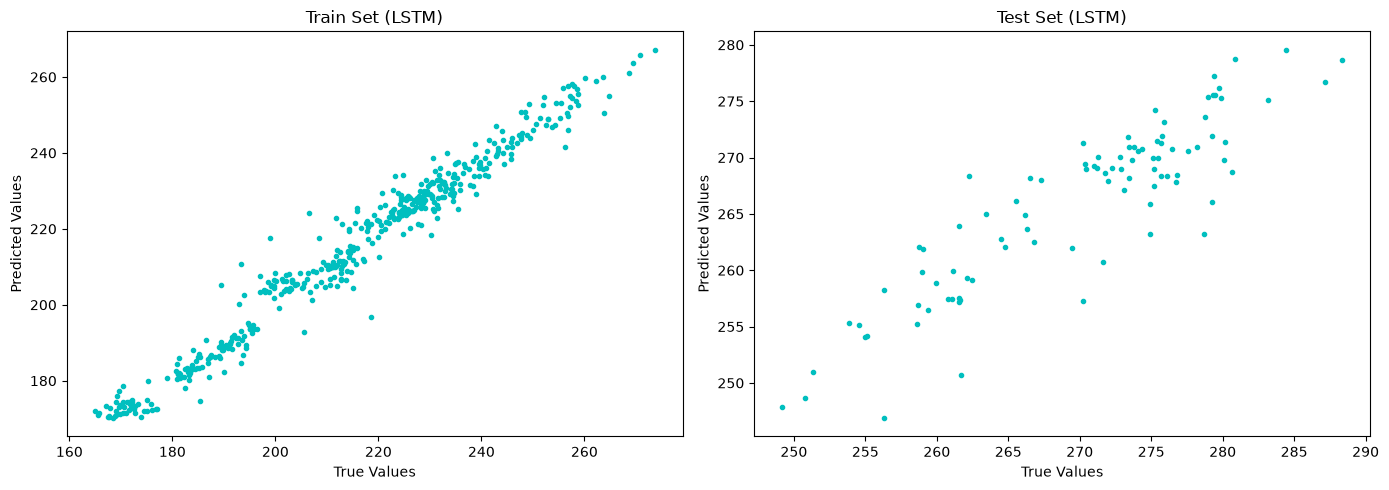

MAE:
  Train: 3.2289
  Test:  4.5412
R^2:
  Train: 0.9681
  Test:  0.5916


In [69]:
n_splits = 5 # Assuming n_splits is 5 as used in previous CV
kf_time_series_reget = TimeSeriesSplit(n_splits=n_splits)

last_train_index = None
last_test_index = None
last_y_train_fold = None
last_y_test_fold = None
last_scaler_y_cv = None

# Iterate through the splits to get the data and scaler for the last fold
# X_recent_2d is assumed to be available from prior cells.
for i, (tr_idx, ts_idx) in enumerate(kf_time_series_reget.split(X_recent_2d)):
    if i == n_splits - 1: # This is the last fold
        last_train_index = tr_idx
        last_test_index = ts_idx
        last_y_train_fold = y_recent[tr_idx]
        last_y_test_fold = y_recent[ts_idx]

        # Recreate scaler_y_cv for the last fold to ensure consistency
        temp_scaler_y_cv = MinMaxScaler(feature_range=(0,1))
        temp_scaler_y_cv.fit(last_y_train_fold.reshape(-1, 1))
        last_scaler_y_cv = temp_scaler_y_cv
        break


y_train_pred_scaled = model_lstm_final.predict(X_train_scaled_3d_cv)
y_test_pred_scaled  = model_lstm_final.predict(X_test_scaled_3d_cv)

# Inverse transform predictions to original scale using the correct scaler_y_cv
y_train_pred = last_scaler_y_cv.inverse_transform(y_train_pred_scaled)
y_test_pred  = last_scaler_y_cv.inverse_transform(y_test_pred_scaled)

# Now use the true values and dates from the last fold's split
y_train_true = last_y_train_fold.reshape(-1, 1)
y_test_true = last_y_test_fold.reshape(-1, 1)
dates_train_plot = dates_recent[last_train_index]
dates_test_plot = dates_recent[last_test_index]

# Create a figure with one subplot for loss
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot Training and Validation Loss
ax.plot(history_lstm_final.history['loss'], label='Training Loss')
ax.plot(history_lstm_final.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss (LSTM)')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Calculate metrics for LSTM model
r2_train = r2_score(y_train_true, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

# Convert predictions to pandas Series with dates as index for plotting
y_train_pred_series = pd.Series(y_train_pred.flatten(), index=dates_train_plot)
y_test_pred_series  = pd.Series(y_test_pred.flatten(), index=dates_test_plot)

# Calculate global y-axis limits for consistent plotting
y_min = min(y_train_true.min(), y_train_pred_series.min(), y_test_true.min(), y_test_pred_series.min())
y_max = max(y_train_true.max(), y_train_pred_series.max(), y_test_true.max(), y_test_pred_series.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_plot, y_train_true, 'r', label='True')
axs[0].plot(y_train_pred_series, 'g', label='Predicted')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test_plot, y_test_true, 'r', label='True')
axs[1].plot(y_test_pred_series, 'g', label='Predicted')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot scatter plots for train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_true, y_train_pred_series.values, 'c.')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test_true, y_test_pred_series.values, 'c.')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train_true, y_train_pred)
mae_test = mean_absolute_error(y_test_true, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

In [70]:
# Create a DataFrame to organize the data of true vs pred data graph
predicted_results_df_corrected = pd.DataFrame({
    'Actual Close Price': pd.Series(y_test_true.flatten(), index=dates_test_plot), # Use y_test_true and dates_test_plot
    'Predicted Stock Price': pd.Series(y_test_pred.flatten(), index=dates_test_plot),
    'Difference (Error)': (pd.Series(y_test_true.flatten(), index=dates_test_plot) - pd.Series(y_test_pred.flatten(), index=dates_test_plot)),
    'Percentage Error (%)': ((abs(pd.Series(y_test_true.flatten(), index=dates_test_plot) - pd.Series(y_test_pred.flatten(), index=dates_test_plot))) / pd.Series(y_test_true.flatten(), index=dates_test_plot)) * 100
})

# Get the original 'Open' prices from the stocks DataFrame using dates_test_plot's index
# Note: 'stocks' DataFrame has 'Open' (capital O) column
open_prices = stocks.loc[dates_test_plot, ['Open']]

# Merge this information into predicted_results_df, aligning by index
predicted_results_df_corrected = predicted_results_df_corrected.merge(open_prices, left_index=True, right_index=True)

# Reorder columns for clarity, putting 'Open' and 'Actual Close Price' first
predicted_results_df_corrected = predicted_results_df_corrected[[
    'Open', 'Actual Close Price', 'Predicted Stock Price',
    'Difference (Error)', 'Percentage Error (%)'
]]

# Sort the DataFrame by its index (dates) to enable proper time-series slicing
predicted_results_df_corrected = predicted_results_df_corrected.sort_index()

# Display the corrected numerical table filtered from 2007 to 2026
display(predicted_results_df_corrected.loc['2025':'2026'])

,Open,Actual Close Price,Predicted Stock Price,Difference (Error),Percentage Error (%)
2025-10-31,276.463053,276.792443,268.485016,8.307427,3.001320
2025-11-03,269.905566,270.334741,269.429901,0.904840,0.334711
2025-11-04,267.819507,270.973499,269.281677,1.691822,0.624349
2025-11-05,268.098980,271.183128,269.106445,2.076683,0.765786
2025-11-06,267.380377,272.879874,268.954346,3.925528,1.438555
...,...,...,...,...,...
2026-03-12,258.660004,258.950012,259.859894,-0.909882,0.351373
2026-03-13,255.479996,256.329987,258.211060,-1.881073,0.733848
2026-03-16,252.110001,253.889999,255.357834,-1.467834,0.578138
2026-03-17,252.960007,255.130005,254.140579,0.989426,0.387812


### Training `model_lstm_final` on a Specific Fold (e.g., Fold 4)

To demonstrate how to train and evaluate the `model_lstm_final` on a specific fold, we will perform the following steps for **Fold 4**:

1.  **Iterate through the `TimeSeriesSplit`** to get the `train_index` and `test_index` for Fold 4.
2.  **Extract the data** (`X_train_fold_4`, `y_train_fold_4`, `X_test_fold_4`, `y_test_fold_4`, `dates_train_fold_4`, `dates_test_fold_4`).
3.  **Scale the data** using new `MinMaxScaler` instances (`scaler_X_fold_4`, `scaler_y_fold_4`) to prevent data leakage from other folds.
4.  **Reshape the scaled X data** to the 3D format required by the LSTM model.
5.  **Build a fresh `model_lstm_final`** with its optimizer and compile it.
6.  **Train the model** using the specific fold's scaled data.
7.  **Evaluate and plot the results** for Fold 4.

Extracted indices for Fold 4
Data for Fold 4 prepared and scaled.

Training model for Fold 4...
Epoch 1/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.3225 - val_loss: 0.4208
Epoch 2/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1896 - val_loss: 0.4291
Epoch 3/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1409 - val_loss: 0.4512
Epoch 4/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1429 - val_loss: 0.4009
Epoch 5/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1203 - val_loss: 0.3798
Epoch 6/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1111 - val_loss: 0.4115
Epoch 7/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0990 - val_loss: 0.3886
Epoch 8/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0963 - val_loss: 0.3776
Epoch 9/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0889 - val_loss: 0.3866
Epoch 10/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0919 - val_loss: 0.3867
Epoch 11/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.09

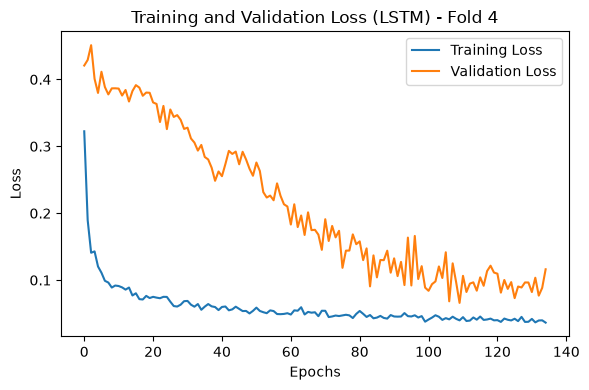

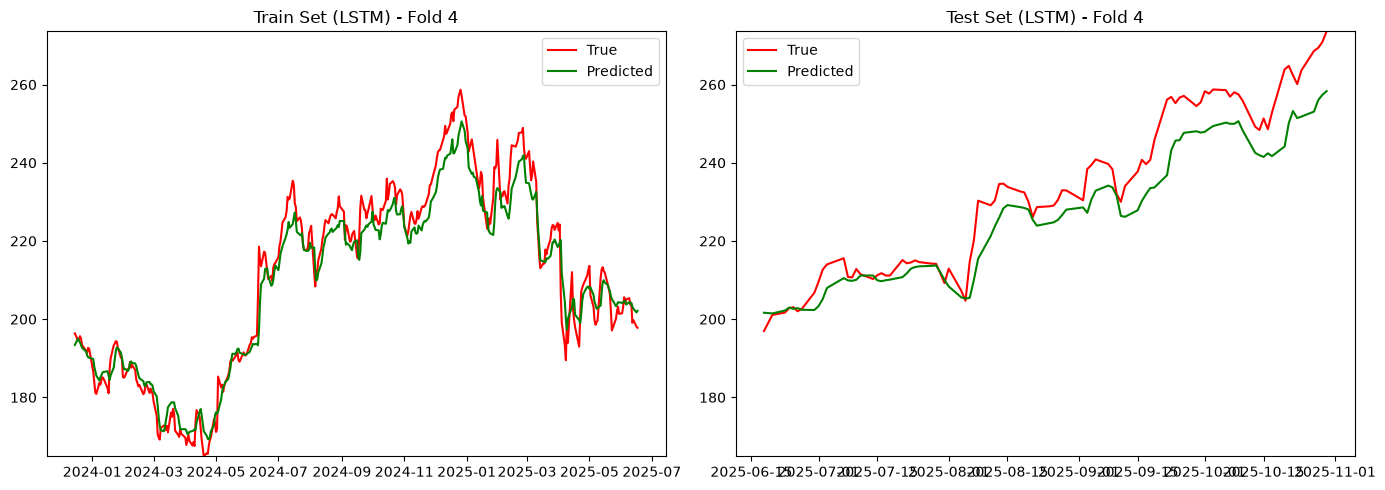

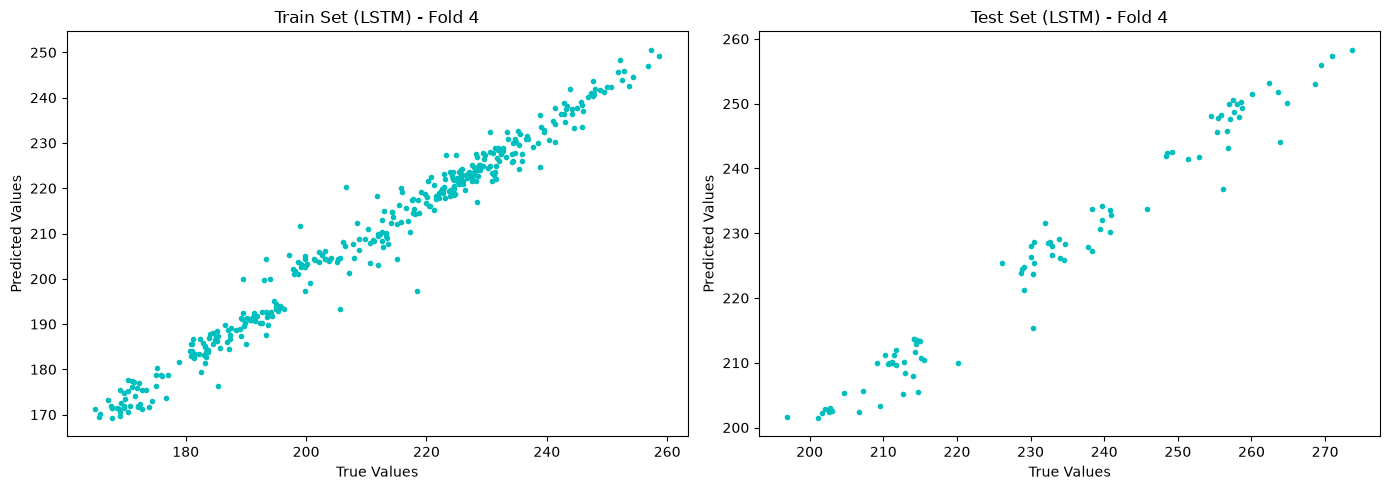

In [71]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Define the LSTM model building function
def build_lstm_model(window_size, num_features, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(window_size, num_features)),
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),
        BatchNormalization(),
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# Re-initialize TimeSeriesSplit
n_splits = 5
kf_time_series = TimeSeriesSplit(n_splits=n_splits)

# X_recent_2d was already created in cell 5fe8341e
# We will iterate to get the 4th fold's indices

selected_fold = 4
current_fold = 0

for train_index, test_index in kf_time_series.split(X_recent_2d):
    current_fold += 1
    if current_fold == selected_fold:
        # Store the indices for the selected fold
        train_index_4 = train_index
        test_index_4 = test_index
        break

print(f"Extracted indices for Fold {selected_fold}")

# Extract data for Fold 4
X_train_fold_4_2d = X_recent_2d[train_index_4]
X_test_fold_4_2d  = X_recent_2d[test_index_4]
y_train_fold_4    = y_recent[train_index_4]
y_test_fold_4     = y_recent[test_index_4]
dates_train_fold_4 = dates_recent[train_index_4]
dates_test_fold_4  = dates_recent[test_index_4]

# Scale data for Fold 4
scaler_X_fold_4 = MinMaxScaler(feature_range=(0, 1))
scaler_y_fold_4 = MinMaxScaler(feature_range=(0, 1))

X_train_scaled_fold_4_2d = scaler_X_fold_4.fit_transform(X_train_fold_4_2d)
X_test_scaled_fold_4_2d  = scaler_X_fold_4.transform(X_test_fold_4_2d)

y_train_scaled_fold_4 = scaler_y_fold_4.fit_transform(y_train_fold_4.reshape(-1, 1))
y_test_scaled_fold_4  = scaler_y_fold_4.transform(y_test_fold_4.reshape(-1, 1))

# Reshape scaled X data to 3D for LSTM input
current_window_size = X_recent.shape[1] # This should be 10
current_num_features = X_recent.shape[2] # This should be 5

X_train_scaled_3d_fold_4 = X_train_scaled_fold_4_2d.reshape((X_train_scaled_fold_4_2d.shape[0], current_window_size, current_num_features))
X_test_scaled_3d_fold_4  = X_test_scaled_fold_4_2d.reshape((X_test_scaled_fold_4_2d.shape[0], current_window_size, current_num_features))

print("Data for Fold 4 prepared and scaled.")

# Build a fresh model for Fold 4
model_lstm_fold_4 = build_lstm_model(
    current_window_size,
    current_num_features,
    dropout_rate=0.2,
    learning_rate=0.001 # Use the optimized learning rate
)

# Early stopping callback
early_stopping_fold_4 = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

print(f"\nTraining model for Fold {selected_fold}...")
history_lstm_fold_4 = model_lstm_fold_4.fit(
    X_train_scaled_3d_fold_4, y_train_scaled_fold_4,
    epochs=250,
    batch_size=64,
    validation_data=(X_test_scaled_3d_fold_4, y_test_scaled_fold_4),
    verbose=1,
    callbacks=[early_stopping_fold_4]
)

print(f"\nEvaluation for Fold {selected_fold}:")
# Get predictions
y_train_pred_scaled_fold_4 = model_lstm_fold_4.predict(X_train_scaled_3d_fold_4)
y_test_pred_scaled_fold_4  = model_lstm_fold_4.predict(X_test_scaled_3d_fold_4)

# Inverse transform predictions to original scale
y_train_pred_fold_4 = scaler_y_fold_4.inverse_transform(y_train_pred_scaled_fold_4)
y_test_pred_fold_4  = scaler_y_fold_4.inverse_transform(y_test_pred_scaled_fold_4)

# Calculate metrics
r2_train_fold_4 = r2_score(y_train_fold_4, y_train_pred_fold_4)
r2_test_fold_4  = r2_score(y_test_fold_4, y_test_pred_fold_4)

rmse_train_fold_4 = mean_squared_error(y_train_fold_4, y_train_pred_fold_4)**0.5
rmse_test_fold_4  = mean_squared_error(y_test_fold_4, y_test_pred_fold_4)**0.5

mae_train_fold_4 = mean_absolute_error(y_train_fold_4, y_train_pred_fold_4)
mae_test_fold_4  = mean_absolute_error(y_test_fold_4, y_test_pred_fold_4)

print("MAE:")
print(f"  Train: {mae_train_fold_4:.4f}")
print(f"  Test:  {mae_test_fold_4:.4f}")
print("R^2:")
print(f"  Train: {r2_train_fold_4:.4f}")
print(f"  Test:  {r2_test_fold_4:.4f}")

# Plotting for Fold 4
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(history_lstm_fold_4.history['loss'], label='Training Loss')
ax.plot(history_lstm_fold_4.history['val_loss'], label='Validation Loss')
ax.set_title(f'Training and Validation Loss (LSTM) - Fold {selected_fold}')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

y_train_pred_series_fold_4 = pd.Series(y_train_pred_fold_4.flatten(), index=dates_train_fold_4)
y_test_pred_series_fold_4  = pd.Series(y_test_pred_fold_4.flatten(), index=dates_test_fold_4)

y_min_fold_4 = min(y_train_fold_4.min(), y_train_pred_series_fold_4.min(), y_test_fold_4.min(), y_test_pred_series_fold_4.min())
y_max_fold_4 = max(y_train_fold_4.max(), y_train_pred_series_fold_4.max(), y_test_fold_4.max(), y_test_pred_series_fold_4.max())

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_fold_4, y_train_fold_4, 'r', label='True')
axs[0].plot(y_train_pred_series_fold_4, 'g', label='Predicted')
axs[0].set_title(f'Train Set (LSTM) - Fold {selected_fold}')
axs[0].set_ylim(y_min_fold_4, y_max_fold_4)
axs[0].legend()

axs[1].plot(dates_test_fold_4, y_test_fold_4, 'r', label='True')
axs[1].plot(y_test_pred_series_fold_4, 'g', label='Predicted')
axs[1].set_title(f'Test Set (LSTM) - Fold {selected_fold}')
axs[1].set_ylim(y_min_fold_4, y_max_fold_4)
axs[1].legend()

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_fold_4, y_train_pred_series_fold_4.values, 'c.')
axs[0].set_title(f'Train Set (LSTM) - Fold {selected_fold}')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')

axs[1].plot(y_test_fold_4, y_test_pred_series_fold_4.values, 'c.')
axs[1].set_title(f'Test Set (LSTM) - Fold {selected_fold}')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')

plt.tight_layout()
plt.show()

### Saving the Trained Model for Specific Fold (e.g., Fold 4)

Now, we will save the `model_lstm_fold_4` which was specifically trained and evaluated on **Fold 4**. This allows you to retain the model's weights and configuration from this particular cross-validation split.

In [72]:
import joblib
model_lstm_fold_4.save('lstm_model_fold_4.keras')
print("LSTM model for Fold 4 saved as 'lstm_model_fold_4.keras'")

# Save the X scaler specific to Fold 4
joblib.dump(scaler_X_fold_4, 'scaler_X_fold_4.pkl')
print("X scaler for Fold 4 saved as 'scaler_X_fold_4.pkl'")

# Save the y scaler specific to Fold 4
joblib.dump(scaler_y_fold_4, 'scaler_y_fold_4.pkl')
print("Y scaler for Fold 4 saved as 'scaler_y_fold_4.pkl'")

LSTM model for Fold 4 saved as 'lstm_model_fold_4.keras'
X scaler for Fold 4 saved as 'scaler_X_fold_4.pkl'
Y scaler for Fold 4 saved as 'scaler_y_fold_4.pkl'


### Saving the Trained Model and Scalers

Now, we will save the retrained LSTM model (`lstm_model.keras`), the fitted X-scaler (`scaler_X.pkl`), and the fitted y-scaler (`scaler_y.pkl`) to your project directory. These files can be loaded later to make new predictions without retraining or re-fitting the scalers.

In [73]:
'''# Save the LSTM model
model_lstm_final.save('lstm_model.keras')
print("LSTM model saved as 'lstm_model.keras'")

# Save the X scaler
joblib.dump(scaler_X_final, 'scaler_X.pkl')
print("X scaler saved as 'scaler_X.pkl'")

# Save the y scaler
joblib.dump(scaler_y_final, 'scaler_y.pkl')
print("Y scaler saved as 'scaler_y.pkl'")'''

'# Save the LSTM model\nmodel_lstm_final.save(\'lstm_model.keras\')\nprint("LSTM model saved as \'lstm_model.keras\'")\n\n# Save the X scaler\njoblib.dump(scaler_X_final, \'scaler_X.pkl\')\nprint("X scaler saved as \'scaler_X.pkl\'")\n\n# Save the y scaler\njoblib.dump(scaler_y_final, \'scaler_y.pkl\')\nprint("Y scaler saved as \'scaler_y.pkl\'")'

### MLflow Tracking Example for LSTM Model

Now, let's log the LSTM model's training details, parameters, and performance metrics to MLflow. We'll use the results from the `model_lstm_fold_4` which was trained on Fold 4 of your time series cross-validation.

In [74]:
import mlflow
import mlflow.keras
from sklearn.metrics import mean_absolute_error, r2_score

# Set an experiment name for the LSTM model
mlflow.set_experiment("Stock Price Prediction - LSTM Model")

with mlflow.start_run():
    # Log parameters specific to the LSTM model (from build_lstm_model and training for Fold 4)
    mlflow.log_param("epochs", 250)
    mlflow.log_param("batch_size", 64)
    mlflow.log_param("dropout_rate", 0.2)
    mlflow.log_param("learning_rate", 0.001)
    mlflow.log_param("loss_function", "mae")
    mlflow.log_param("window_size", 10)
    mlflow.log_param("num_features", X_recent.shape[2]) # Get from X_recent as used in CV

    # Log metrics (using the results from the Fold 4 evaluation)
    mlflow.log_metric("train_mae", mae_train_fold_4)
    mlflow.log_metric("test_mae", mae_test_fold_4)
    mlflow.log_metric("train_r2", r2_train_fold_4)
    mlflow.log_metric("test_r2", r2_test_fold_4)
    mlflow.log_metric("train_rmse", rmse_train_fold_4)
    mlflow.log_metric("test_rmse", rmse_test_fold_4)

    # Log the Keras LSTM model for Fold 4
    mlflow.keras.log_model(model_lstm_fold_4, "lstm_model_fold_4")

    print("MLflow Run for LSTM model completed.")

2026/06/16 21:54:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 21:54:13 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


MLflow Run for LSTM model completed.


### Viewing MLflow UI in Colab

To view the MLflow UI directly within Colab, we can use `ngrok` to expose the local MLflow server to a public URL. This requires installing `pyngrok` and providing an `ngrok` authtoken.

1.  **Get an `ngrok` Authtoken:** If you don't have one, sign up at [ngrok.com](https://ngrok.com/) and get your authtoken from your dashboard.
2.  **Add to Colab Secrets:** Store your `ngrok` authtoken securely in Colab Secrets (click the "🔑" icon on the left panel) under the name `NGROK_AUTH_TOKEN`.
3.  **Run the cells below** to install `pyngrok`, set the authtoken, and launch the MLflow UI.

In [75]:
# Install pyngrok to tunnel the MLflow UI
!pip install pyngrok -q

In [76]:
import os
from google.colab import userdata

# Get your ngrok authtoken from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Set the authtoken
!ngrok authtoken {NGROK_AUTH_TOKEN}

print("ngrok authtoken configured.")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
ngrok authtoken configured.


In [77]:
import subprocess
import threading
import time
from pyngrok import ngrok

def run_mlflow_ui():
    # Start MLflow UI in a background process
    print("Starting MLflow UI...")
    mlflow_process = subprocess.Popen(["mlflow", "ui", "--host", "0.0.0.0"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    print("MLflow UI process started. Waiting for it to become available...")
    # Give MLflow UI some time to start
    time.sleep(5)
    for _ in range(30):
        if mlflow_process.poll() is not None: # If process exited, something went wrong
            stdout, stderr = mlflow_process.communicate()
            print(f"MLflow UI process exited with code {mlflow_process.returncode}")
            print(f"STDOUT: {stdout.decode()}")
            print(f"STDERR: {stderr.decode()}")
            raise RuntimeError("MLflow UI failed to start.")
        print("Checking for MLflow UI availability...")
        # More robust check could involve trying to connect to the port
        time.sleep(2)
    print("MLflow UI should be running locally now.")
    return mlflow_process

# Run MLflow UI in a separate thread
mlflow_thread = threading.Thread(target=run_mlflow_ui)
mlflow_thread.daemon = True
mlflow_thread.start()

# Wait for MLflow UI to start (adjust sleep time if necessary)
time.sleep(10)

# Create a public URL for the MLflow UI using ngrok
print("Creating ngrok tunnel...")
# The default MLflow UI port is 5000
public_url = ngrok.connect(5000)
print(f"MLflow UI is available at: {public_url}")

Starting MLflow UI...
MLflow UI process started. Waiting for it to become available...


Exception in thread Thread-8 (run_mlflow_ui):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_671674/3959138850.py", line 19, in run_mlflow_ui
RuntimeError: MLflow UI failed to start.


MLflow UI process exited with code 0
STDOUT: Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.

STDERR: [MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
/usr/local/lib/python3.12/dist-packages/mlflow/server/fastapi_app.py:17: StarletteDeprecationWarning: starlette.middleware.wsgi is deprecated and will be removed in a future release. Please refer to https://github.com/abersheeran/a2wsgi as a replacement.
  from starlette.middleware.wsgi import WSGIResponder, build_environ
2026/06/16 21:54:24 ERROR:    [Errno 98] Address already in use

Creating ngrok tunnel...
MLflow UI is available at: NgrokTunnel: "https://army-repossess-ashen.ngrok-free.dev" -> "http://localhost:5000"


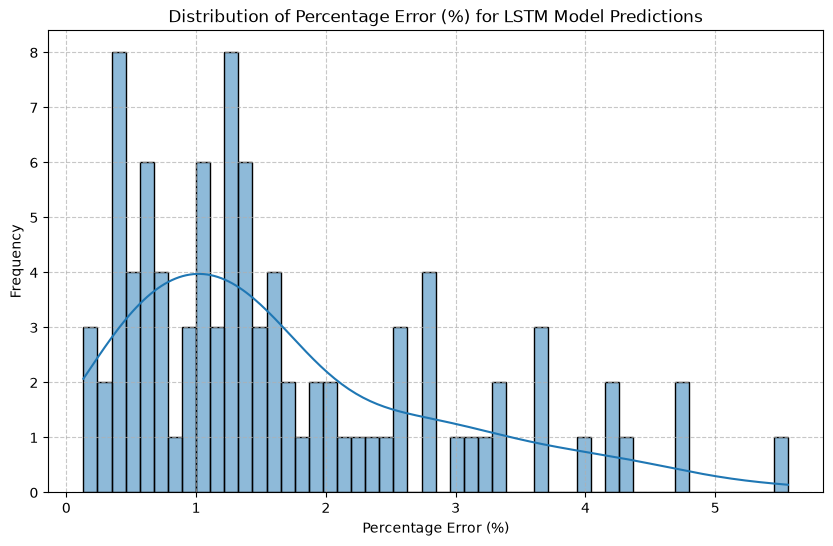

In [78]:
plt.figure(figsize=(10, 6))
sns.histplot(predicted_results_df_corrected['Percentage Error (%)'], bins=50, kde=True)
plt.title('Distribution of Percentage Error (%) for LSTM Model Predictions')
plt.xlabel('Percentage Error (%)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()